VARIABLE RELATIONSHIPS WITH NO_FLUIDO

In [7]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.0 MB/s eta 0:00:00


In [ ]:
"""
Análisis de relación entre climatología y tráfico (Estado)
Dataset: dataset_final.csv
Estado: 0=Fluido, 1=Denso, 2=Congestionado, 3=Muy congestionado
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv("dataset_final.csv")

# Asume que ya tienes el DataFrame cargado en la variable `df`
print(f"Filas cargadas: {len(df):,}")
print("Columnas:", df.columns.tolist())

# =============================================================
# 2. PREPARACIÓN
# =============================================================
df['fecha']    = pd.to_datetime(df['fecha'])
df['hora_num'] = pd.to_datetime(df['hora'], format='%H:%M:%S').dt.hour
df['no_fluido'] = (df['Estado'] > 0).astype(int)

# Hora punta: mañana (7-9h) y tarde (14-16h)
df['punta'] = df['hora_num'].isin([7, 8, 9, 14, 15, 16]).astype(int)

# Categoría de lluvia
df['lluvia_cat'] = pd.cut(
    df['prec'],
    bins=[-1, 0, 2, 10, 1000],
    labels=['Sin lluvia', 'Suave (<2mm)', 'Moderada (2-10mm)', 'Intensa (>10mm)']
)

# Agregación diaria (una fila por día, promedio de Estado)
por_dia = df.groupby('fecha').agg(
    tmed          = ('tmed',      'first'),
    prec          = ('prec',      'first'),
    tmin          = ('tmin',      'first'),
    tmax          = ('tmax',      'first'),
    sol           = ('sol',       'first'),
    pct_no_fluido = ('no_fluido', 'mean')
).reset_index()

por_dia['cuartil_temp'] = pd.qcut(
    por_dia['tmed'], 4,
    labels=['Fría\n(<15°C)', 'Fresca\n(15-20°C)', 'Cálida\n(20-25°C)', 'Caliente\n(>25°C)']
)

# =============================================================
# 3. CORRELACIONES
# =============================================================
print("\n--- CORRELACIONES con % tráfico no fluido ---")
corr = por_dia[['tmed', 'prec', 'tmin', 'tmax', 'sol', 'pct_no_fluido']].corr()
print(corr['pct_no_fluido'].sort_values())

# =============================================================
# 4. VISUALIZACIONES
# =============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Relación Climatología → Tráfico No Fluido (Estado > 0)",
    fontsize=15, fontweight='bold', y=1.01
)

palette = "#e74c3c"
scatter_kw = dict(alpha=0.35, s=18, color="#2c3e50")

# --- 4.1 Temperatura media vs % no fluido ---
ax = axes[0, 0]
ax.scatter(por_dia['tmed'], por_dia['pct_no_fluido'] * 100, **scatter_kw)
m, b = np.polyfit(por_dia['tmed'].dropna(), por_dia.loc[por_dia['tmed'].notna(), 'pct_no_fluido'] * 100, 1)
x_line = np.linspace(por_dia['tmed'].min(), por_dia['tmed'].max(), 100)
ax.plot(x_line, m * x_line + b, color=palette, linewidth=2)
ax.set_xlabel("Temperatura media (°C)")
ax.set_ylabel("% registros no fluidos")
ax.set_title(f"Temp. media  |  r = {por_dia['tmed'].corr(por_dia['pct_no_fluido']):.3f}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# --- 4.2 Precipitación vs % no fluido ---
ax = axes[0, 1]
ax.scatter(por_dia['prec'], por_dia['pct_no_fluido'] * 100, **scatter_kw)
m2, b2 = np.polyfit(por_dia['prec'].dropna(), por_dia.loc[por_dia['prec'].notna(), 'pct_no_fluido'] * 100, 1)
x2 = np.linspace(0, por_dia['prec'].max(), 100)
ax.plot(x2, m2 * x2 + b2, color=palette, linewidth=2)
ax.set_xlabel("Precipitación (mm)")
ax.set_ylabel("% registros no fluidos")
ax.set_title(f"Precipitación  |  r = {por_dia['prec'].corr(por_dia['pct_no_fluido']):.3f}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# --- 4.3 Horas de sol vs % no fluido ---
ax = axes[0, 2]
ax.scatter(por_dia['sol'], por_dia['pct_no_fluido'] * 100, **scatter_kw)
m3, b3 = np.polyfit(por_dia['sol'].dropna(), por_dia.loc[por_dia['sol'].notna(), 'pct_no_fluido'] * 100, 1)
x3 = np.linspace(0, por_dia['sol'].max(), 100)
ax.plot(x3, m3 * x3 + b3, color=palette, linewidth=2)
ax.set_xlabel("Horas de sol")
ax.set_ylabel("% registros no fluidos")
ax.set_title(f"Horas de sol  |  r = {por_dia['sol'].corr(por_dia['pct_no_fluido']):.3f}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# --- 4.4 Cuartiles de temperatura ---
ax = axes[1, 0]
medias_temp = por_dia.groupby('cuartil_temp', observed=True)['pct_no_fluido'].mean() * 100
bars = ax.bar(medias_temp.index, medias_temp.values, color=["#3498db", "#2ecc71", "#f39c12", "#e74c3c"])
ax.set_xlabel("Rango de temperatura")
ax.set_ylabel("% medio no fluido")
ax.set_title("% No fluido por temperatura")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars, medias_temp.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}%", ha='center', va='bottom', fontsize=9)

# --- 4.5 Intensidad de lluvia ---
ax = axes[1, 1]
medias_lluvia = df.groupby('lluvia_cat', observed=True)['no_fluido'].mean() * 100
bars2 = ax.bar(medias_lluvia.index, medias_lluvia.values,
               color=["#95a5a6", "#5dade2", "#2980b9", "#1a5276"])
ax.set_xlabel("Intensidad de lluvia")
ax.set_ylabel("% medio no fluido")
ax.set_title("% No fluido por intensidad de lluvia")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars2, medias_lluvia.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}%", ha='center', va='bottom', fontsize=9)

# --- 4.6 Lluvia x Hora punta ---
ax = axes[1, 2]
tabla = df.groupby(['punta', (df['prec'] > 0).rename('lluvia')])['no_fluido'].mean() * 100
tabla = tabla.unstack()
tabla.index = ['Fuera de punta', 'Hora punta']
tabla.columns = ['Sin lluvia', 'Con lluvia']
tabla.plot(kind='bar', ax=ax, color=["#95a5a6", "#2980b9"], rot=0, edgecolor='white')
ax.set_xlabel("")
ax.set_ylabel("% medio no fluido")
ax.set_title("Lluvia x Hora punta")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig("analisis_clima_trafico.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfica guardada en: analisis_clima_trafico.png")

# =============================================================
# 5. RESUMEN NUMÉRICO
# =============================================================
print("\n========== RESUMEN ==========")
print(f"\nDistribución de Estado:")
print(df['Estado'].value_counts(normalize=True).mul(100).round(2).to_string())

print(f"\nCorrelaciones (valor absoluto):")
vars_clima = ['tmed', 'tmin', 'tmax', 'prec', 'sol']
for v in vars_clima:
    r = por_dia[v].corr(por_dia['pct_no_fluido'])
    print(f"  {v:<8}: {r:+.4f}  {'← débil' if abs(r) < 0.15 else '← moderada'}")

print(f"\n% no fluido con lluvia vs sin lluvia:")
print(f"  Sin lluvia : {df[df['prec']==0]['no_fluido'].mean()*100:.3f}%")
print(f"  Con lluvia : {df[df['prec']>0]['no_fluido'].mean()*100:.3f}%")

print("\nCONCLUSIÓN: La climatología tiene correlación muy débil con el tráfico.")
print("El patrón de congestión está dominado por hora del día y día de la semana.")

Heatmap Correlation

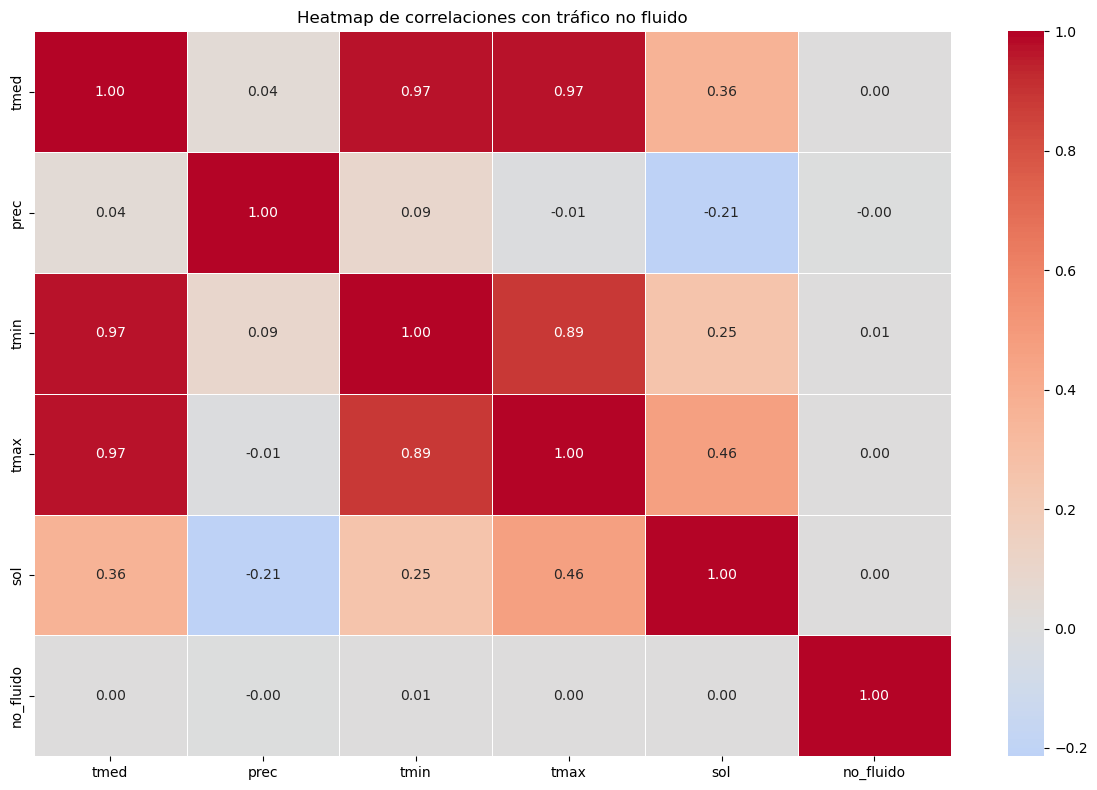


--- CORRELACIÓN CON TRÁFICO NO FLUIDO ---
no_fluido    1.000000
tmin         0.005426
tmed         0.004604
tmax         0.003406
sol          0.003104
prec        -0.002994
Name: no_fluido, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================
# PREPARACIÓN
# =============================================================

df = pd.read_csv("dataset_final.csv")

df['fecha'] = pd.to_datetime(df['fecha'])

# 0 = fluido
# 1 = no fluido (Estado 1,2,3)
df['no_fluido'] = (df['Estado'] > 0).astype(int)

# =============================================================
# VARIABLES NUMÉRICAS
# =============================================================

variables = [
    'tmed',
    'prec',
    'tmin',
    'tmax',
    'sol',
    'no_fluido'
]

# =============================================================
# MATRIZ DE CORRELACIÓN
# =============================================================

corr_matrix = df[variables].corr()

# =============================================================
# HEATMAP
# =============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap de correlaciones con tráfico no fluido')
plt.tight_layout()
plt.show()

# =============================================================
# CORRELACIONES SOLO CON no_fluido
# =============================================================

print("\n--- CORRELACIÓN CON TRÁFICO NO FLUIDO ---")

corr_no_fluido = (
    corr_matrix['no_fluido']
    .sort_values(ascending=False)
)

print(corr_no_fluido)

Traffic Relation with day of week and time of day

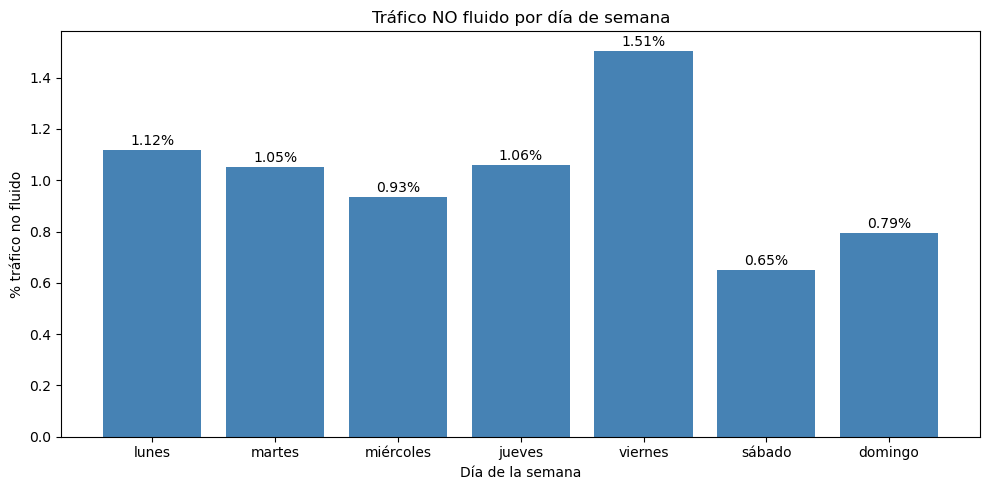

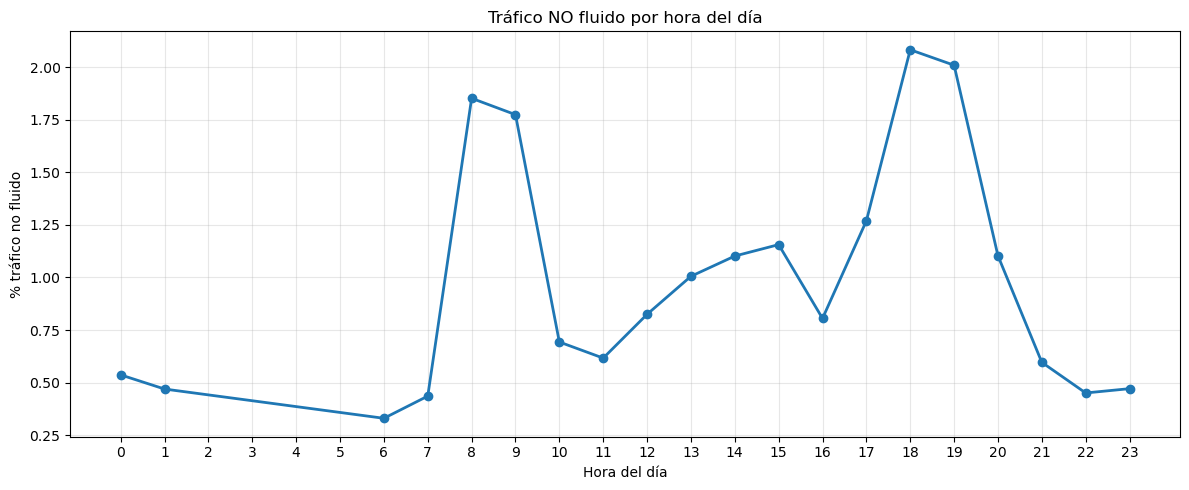

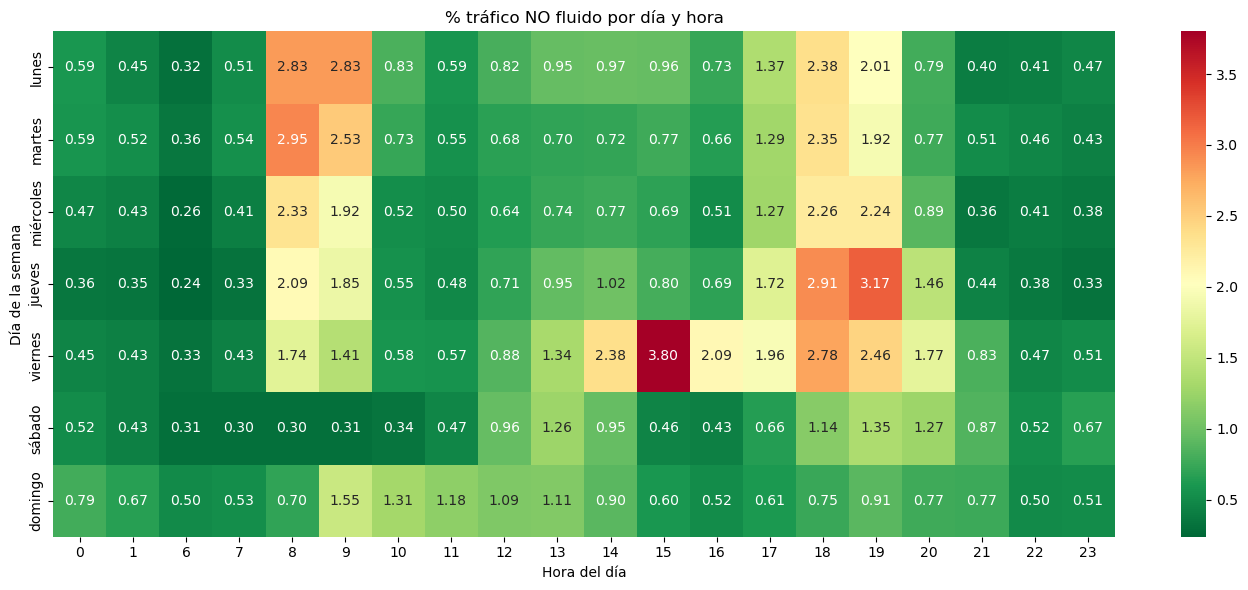

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================
# PREPARACIÓN
# =============================================================

# Variable binaria:
# 0 = fluido
# 1 = no fluido
df['no_fluido'] = (df['Estado'] > 0).astype(int)

# Crear hora_num si no existe
if 'hora_num' not in df.columns:
    df['hora_num'] = pd.to_datetime(
        df['hora'],
        format='%H:%M:%S'
    ).dt.hour

# =============================================================
# LIMPIEZA DÍAS SEMANA
# =============================================================

df['Day_of_week'] = (
    df['Day_of_week']
    .str.lower()
    .replace({
        'miercoles': 'miércoles',
        'sabado': 'sábado'
    })
)

# Orden correcto
orden_dias = [
    'lunes',
    'martes',
    'miércoles',
    'jueves',
    'viernes',
    'sábado',
    'domingo'
]

# =============================================================
# 1. TRÁFICO NO FLUIDO POR DÍA SEMANA
# =============================================================

dia_stats = (
    df.groupby('Day_of_week')['no_fluido']
    .mean()
    .reindex(orden_dias) * 100
)

plt.figure(figsize=(10,5))

plt.bar(
    dia_stats.index,
    dia_stats.values,
    color='steelblue'
)

plt.ylabel('% tráfico no fluido')
plt.xlabel('Día de la semana')

plt.title('Tráfico NO fluido por día de semana')

for i, v in enumerate(dia_stats.values):
    plt.text(i, v + 0.02, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

# =============================================================
# 2. TRÁFICO NO FLUIDO POR HORA
# =============================================================

hora_stats = (
    df.groupby('hora_num')['no_fluido']
    .mean() * 100
)

plt.figure(figsize=(12,5))

plt.plot(
    hora_stats.index,
    hora_stats.values,
    marker='o',
    linewidth=2
)

plt.xticks(range(0,24))

plt.xlabel('Hora del día')
plt.ylabel('% tráfico no fluido')

plt.title('Tráfico NO fluido por hora del día')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================
# 3. HEATMAP DÍA vs HORA
# =============================================================

tabla_heatmap = pd.pivot_table(
    df,
    values='no_fluido',
    index='Day_of_week',
    columns='hora_num',
    aggfunc='mean'
).reindex(orden_dias) * 100

plt.figure(figsize=(14,6))

sns.heatmap(
    tabla_heatmap,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.2f'
)

plt.title('% tráfico NO fluido por día y hora')

plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')

plt.tight_layout()
plt.show()

Traffic Correlation with season

In [ ]:
# =============================================================
# CORRELACIÓN POR ESTACIÓN DEL AÑO
# =============================================================

df["no_fluido"] = (df["Estado"] > 0).astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

df["season"] = df["fecha"].dt.month.apply(get_season)
por_dia["season"] = por_dia["fecha"].dt.month.apply(get_season)

print("\n--- % tráfico no fluido por estación ---")
season_summary = df.groupby("season")["no_fluido"].mean().mul(100).round(3)
print(season_summary)

print("\n--- CORRELACIONES por estación con % tráfico no fluido ---")
vars_clima = ["tmed", "tmin", "tmax", "prec", "sol"]

for season in ["winter", "spring", "summer", "autumn"]:
    subset = por_dia[por_dia["season"] == season]

    print(f"\n{season.upper()}")
    for v in vars_clima:
        r = subset[v].corr(subset["pct_no_fluido"])
        print(f"  {v:<8}: {r:+.4f}")


--- % tráfico no fluido por estación ---
season
autumn    1.227
spring    1.053
summer    0.955
winter    0.833
Name: no_fluido, dtype: float64

--- CORRELACIONES por estación con % tráfico no fluido ---

WINTER
  tmed    : -0.0115
  tmin    : +0.0548
  tmax    : -0.0736
  prec    : +0.0512
  sol     : +0.0558

SPRING
  tmed    : -0.1840
  tmin    : -0.1645
  tmax    : -0.1635
  prec    : +0.0487
  sol     : -0.0992

SUMMER
  tmed    : +0.1675
  tmin    : +0.1324
  tmax    : +0.1646
  prec    : -0.0599
  sol     : +0.1422

AUTUMN
  tmed    : +0.1411
  tmin    : +0.1322
  tmax    : +0.1321
  prec    : -0.0930
  sol     : +0.0962


Experiment with multiple models

Creating lag feature estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Selected features (11):
['estado_lag_4', 'Denominació / Denominación', 'hour_sin', 'hour_cos', 'tmed', 'week_of_year', 'Day_of_week', 'School_holiday', 'Mascletá/Crida', 'is_weekend', 'is_night']

After resampling: 200000 rows
Estado_binary
0    100000
1    100000
Name: count, dtype: int64

TRAINING MULTIPLE MODELS

----------------------------------------------------------------------------------------------------
Training model: LightGBM_cw5
----------------------------------------------------------------------------------------------------

Best result:
Threshold:          0.95
Macro F1:           0.7914
Precision minority: 0.5996
Recall minority:    0.5802
F1 minority:        0.5897
Confusion matrix:
[[1236149    8262]
 [   8951   12372]]

----------------------------------------------------------------------------------------------------
Training model: LightGBM_c

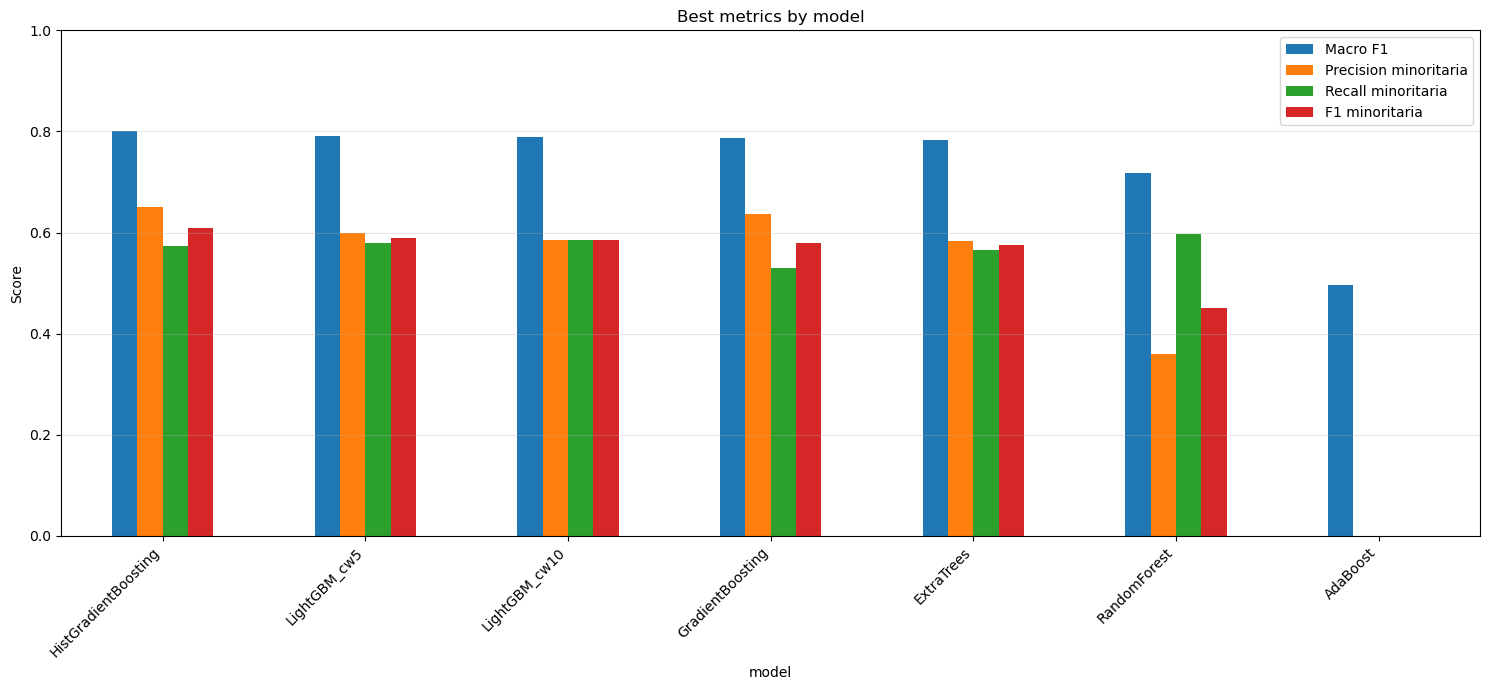

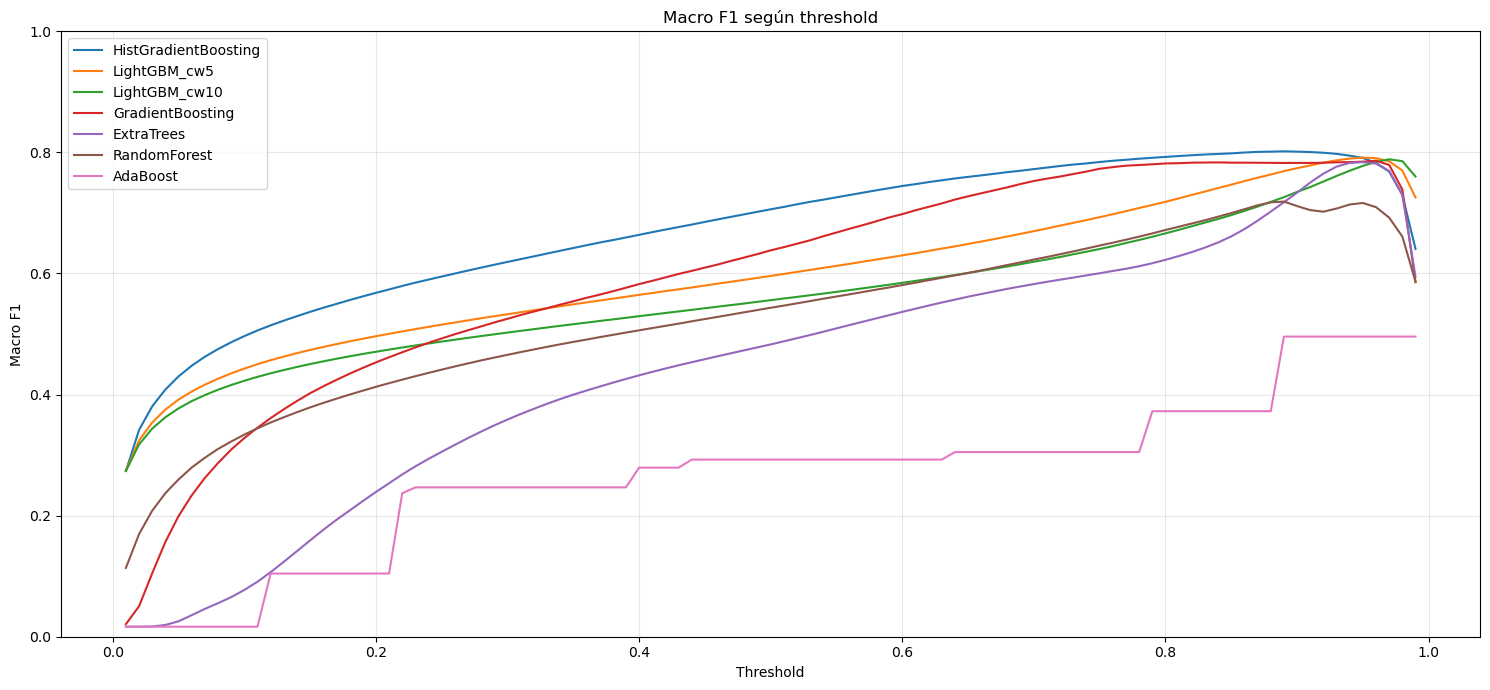

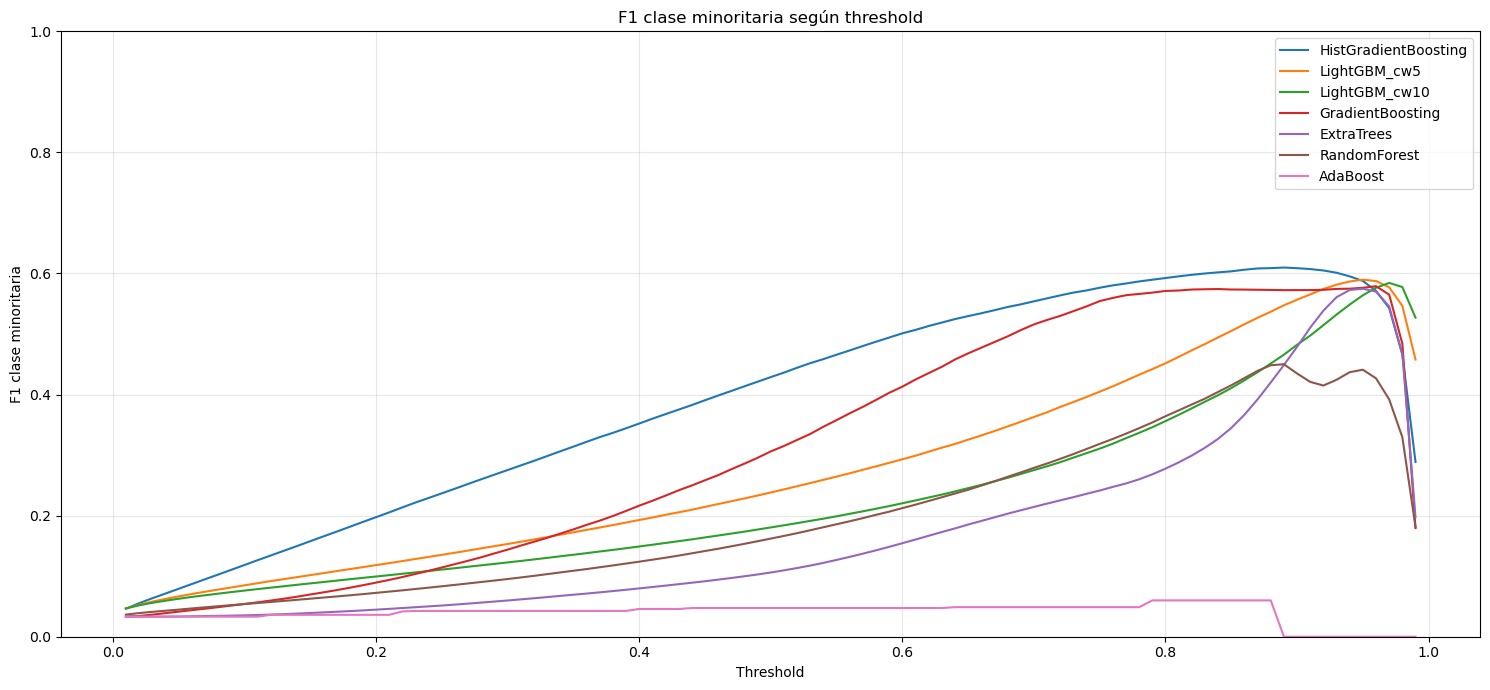

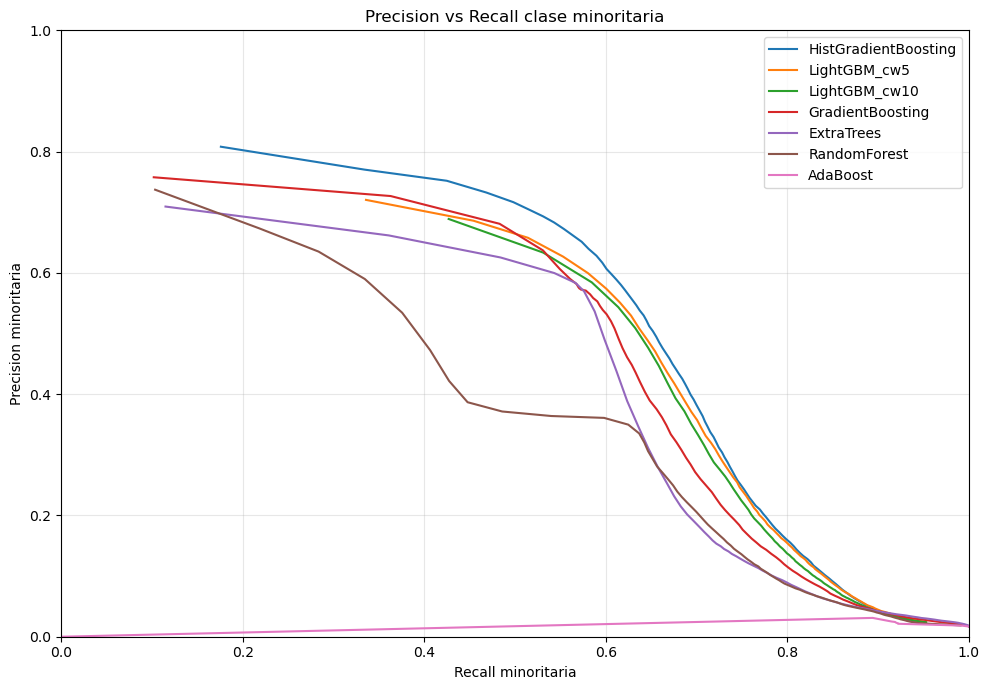


BEST MODEL: HistGradientBoosting
model                 HistGradientBoosting
threshold                             0.89
macro_f1                          0.801775
weighted_f1                       0.987254
accuracy                          0.987642
precision_minority                0.651356
recall_minority                   0.573278
f1_minority                       0.609828
precision_majority                0.992703
recall_majority                   0.994742
f1_majority                       0.993722
tn                                 1237868
fp                                    6543
fn                                    9099
tp                                   12224


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. Load dataset
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. Create lag_4
# ─────────────────────────────────────────────

print("Creating lag feature estado_lag_4...")

grouped = df.groupby("Denominació / Denominación")

df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. Train / test split
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. Feature engineering
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["week_of_year"] = (
        df["fecha"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["is_weekend"] = (
        df["fecha"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. Encode categorical
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. Selected features
# ─────────────────────────────────────────────

selected_features = [
    "estado_lag_4",
    "Denominació / Denominación",
    "hour_sin",
    "hour_cos",
    "tmed",
    "week_of_year",
    "Day_of_week",
    "School_holiday",
    "Mascletá/Crida",
    "is_weekend",
    "is_night",
]

selected_features = [
    f for f in selected_features
    if f in train_df.columns
]

print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]


# ─────────────────────────────────────────────
# 7. Scaling
# ─────────────────────────────────────────────

continuous_cols = [
    "hour_sin",
    "hour_cos",
    "tmed",
    "week_of_year",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. Resampling
# ─────────────────────────────────────────────

TARGET_SAMPLES = 100000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. Models
# ─────────────────────────────────────────────

models = {
    "LightGBM_cw5": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=5,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "LightGBM_cw10": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=10,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=50,
            class_weight={0: 1, 1: 5},
            random_state=42
        ),
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=50,
        subsample=0.8,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. Thresholds 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. Train and evaluate
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING MULTIPLE MODELS")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1": f1_score(
                y_test,
                y_pred,
                average="macro"
            ),

            "weighted_f1": f1_score(
                y_test,
                y_pred,
                average="weighted"
            ),

            "accuracy": accuracy_score(
                y_test,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        all_results.append(result)

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1"].idxmax()
    ]

    print("\nBest result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1:           {best_row['macro_f1']:.4f}")
    print(f"Precision minority: {best_row['precision_minority']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority']:.4f}")
    print("Confusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. Results DataFrames
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 RESULTS ALL MODELS + THRESHOLDS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1", ascending=False)
)

print("\n" + "=" * 100)
print("BEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. Plot best metrics by model
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best metrics by model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision minoritaria",
    "Recall minoritaria",
    "F1 minoritaria",
])

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. Plot Macro F1 by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():
    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1"],
        label=model_name
    )

plt.title("Macro F1 según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 15. Plot F1 minority by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():
    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority"],
        label=model_name
    )

plt.title("F1 clase minoritaria según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 clase minoritaria")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 16. Precision vs Recall minority
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 7))

for model_name in results_df["model"].unique():
    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority"],
        tmp["precision_minority"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria")
plt.xlabel("Recall minoritaria")
plt.ylabel("Precision minoritaria")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 17. Feature importance best model
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "feature": selected_features,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_df["importance_pct"] = (
        importance_df["importance"]
        / importance_df["importance"].sum()
    )

    print("\n" + "=" * 100)
    print("FEATURE IMPORTANCE")
    print("=" * 100)

    print(importance_df.to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating lag feature estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Using ALL features (39):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING MODELS WITH ALL FEATURES

--------------------------------------------

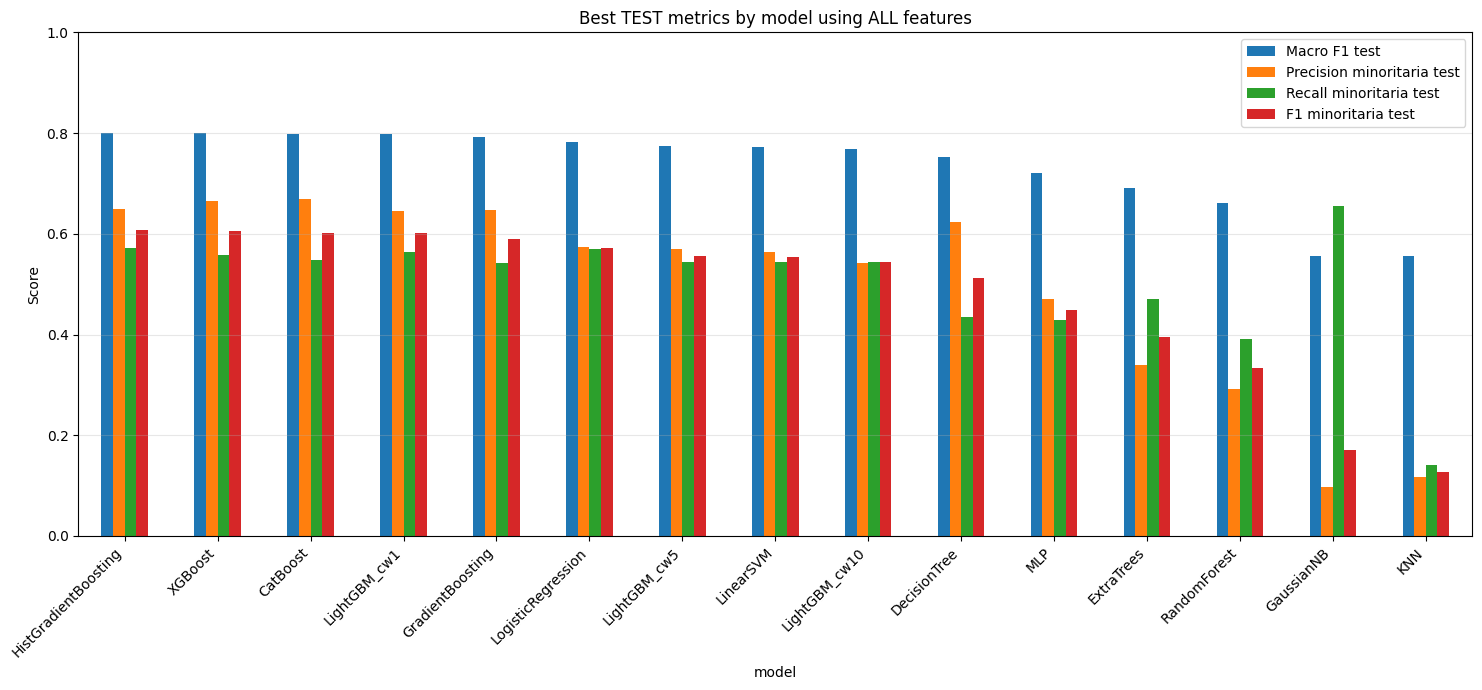

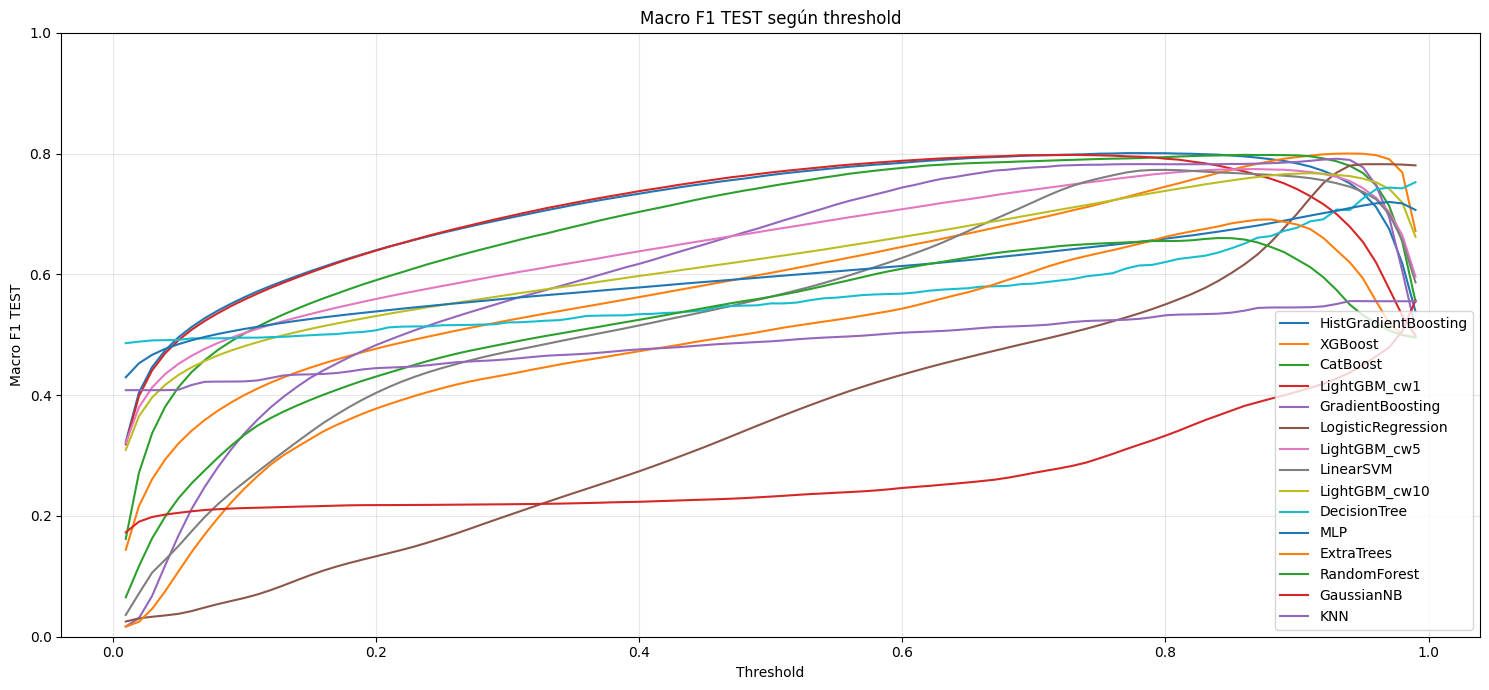

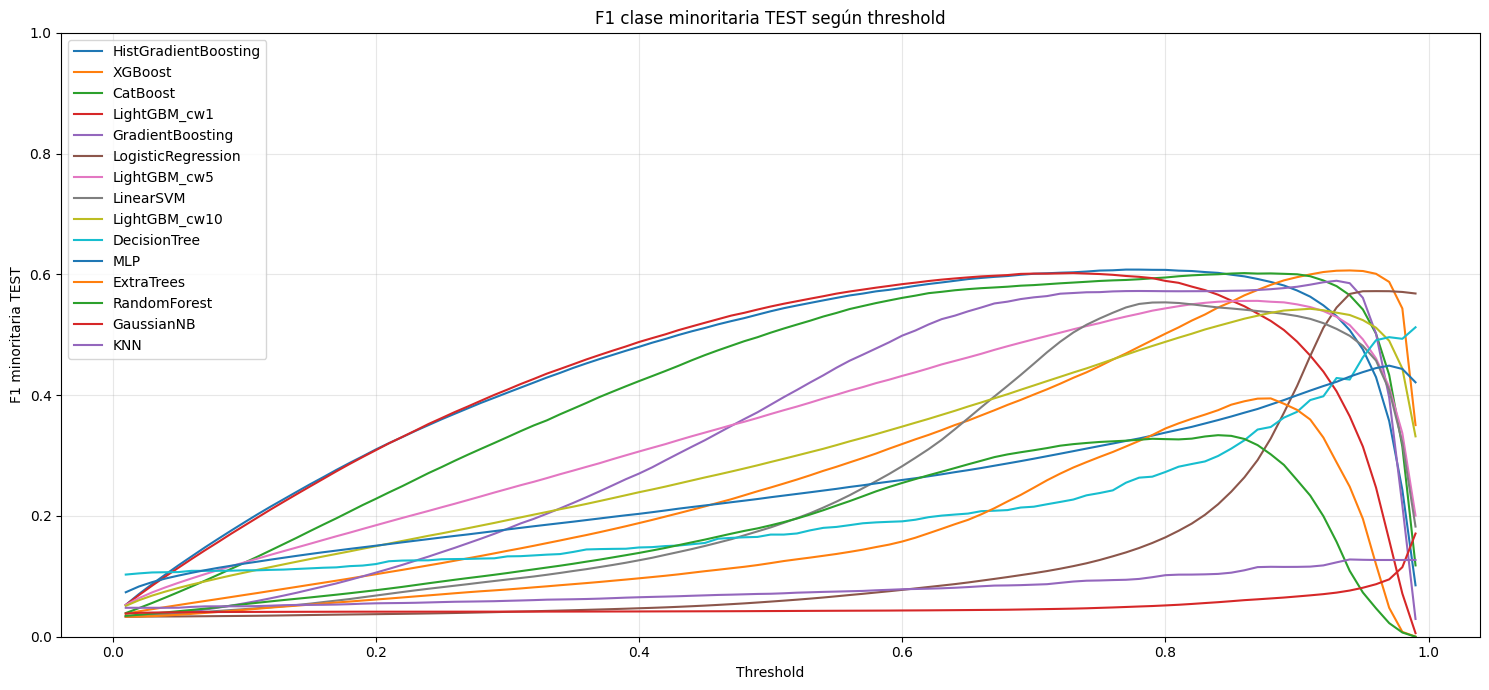

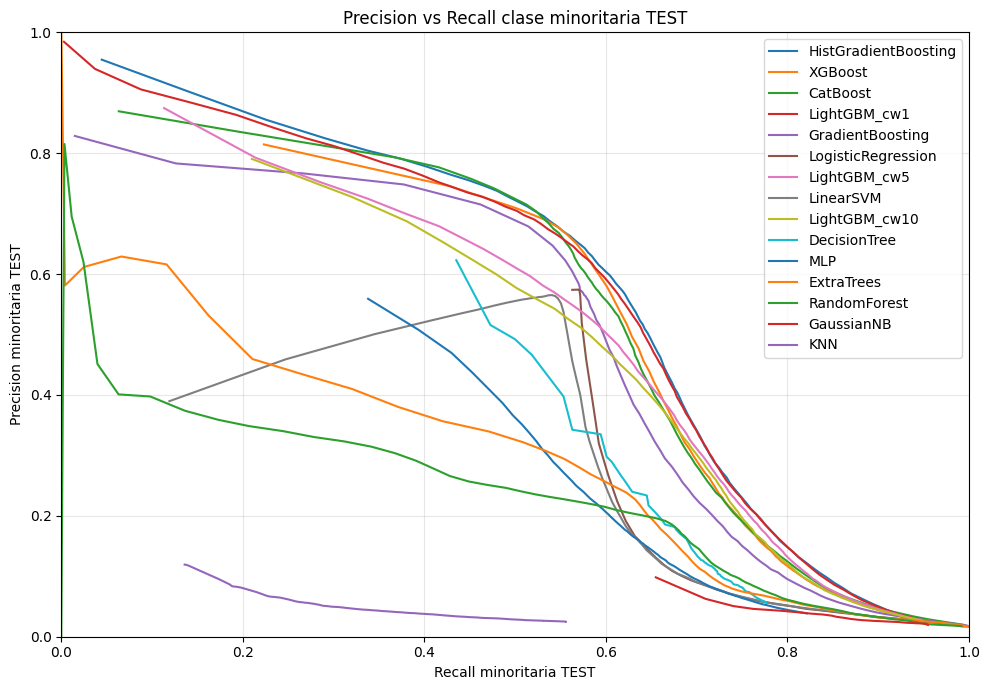


BEST TEST MODEL: HistGradientBoosting
model                      HistGradientBoosting
threshold                                  0.78
macro_f1_test                          0.800806
weighted_f1_test                       0.987188
accuracy_test                          0.987572
precision_minority_test                0.648774
recall_minority_test                   0.571918
f1_minority_test                       0.607926
precision_majority_test                 0.99268
recall_majority_test                   0.994695
f1_majority_test                       0.993686
tn                                      1237809
fp                                         6602
fn                                         9128
tp                                        12195


In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. Load dataset
# ─────────────────────────────────────────────

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. Create lag_4
# ─────────────────────────────────────────────

print("Creating lag feature estado_lag_4...")

grouped = df.groupby("Denominació / Denominación")

df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(subset=["estado_lag_4"]).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. Train / test split
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. Feature engineering
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = (
        df["fecha"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["is_weekend"] = (
        df["fecha"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. Encode categorical
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. Use ALL features
# ─────────────────────────────────────────────

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ALL features ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. Scaling
# ─────────────────────────────────────────────

continuous_cols = [
    "tmed",
    "prec",
    "tmin",
    "tmax",
    "sol",
    "minutes",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. Resampling train only
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. Models
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 9. MODELS (AMPLIADOS)
# ─────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {

    # =========================================================
    # LIGHTGBM
    # =========================================================

    "LightGBM_cw1": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=1,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "LightGBM_cw5": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=5,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "LightGBM_cw10": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=10,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    # =========================================================
    # XGBOOST
    # =========================================================

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=5,
        random_state=42,
        n_jobs=-1
    ),

    # =========================================================
    # CATBOOST
    # =========================================================

    "CatBoost": CatBoostClassifier(
        iterations=400,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=0,
        random_state=42
    ),

    # =========================================================
    # HIST GRADIENT BOOSTING
    # =========================================================

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    # =========================================================
    # EXTRA TREES
    # =========================================================

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    # =========================================================
    # RANDOM FOREST
    # =========================================================

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    # =========================================================
    # GRADIENT BOOSTING
    # =========================================================

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=50,
        subsample=0.8,
        random_state=42
    ),

    # =========================================================
    # LOGISTIC REGRESSION
    # =========================================================

    "LogisticRegression": LogisticRegression(
        class_weight={0: 1, 1: 5},
        max_iter=3000,
        n_jobs=-1,
        random_state=42
    ),

    # =========================================================
    # DECISION TREE
    # =========================================================

    "DecisionTree": DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=20,
        class_weight={0: 1, 1: 5},
        random_state=42
    ),

    # =========================================================
    # KNN
    # =========================================================

    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1
    ),

    # =========================================================
    # NAIVE BAYES
    # =========================================================

    "GaussianNB": GaussianNB(),

    # =========================================================
    # MLP
    # =========================================================

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        random_state=42
    ),

    # =========================================================
    # LINEAR SVM
    # =========================================================

    "LinearSVM": CalibratedClassifierCV(
        LinearSVC(
            class_weight={0: 1, 1: 5},
            random_state=42,
            max_iter=5000
        )
    ),
}



# ─────────────────────────────────────────────
# 10. Thresholds 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. Train and evaluate on TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING MODELS WITH ALL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        all_results.append(result)

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("Confusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. Results table
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. Plot best metrics by model
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics by model using ALL features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. Macro F1 by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 15. F1 minority by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 16. Precision vs Recall minority
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 7))

for model_name in results_df["model"].unique():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 17. Feature importance best model
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_df["importance_pct"] = (
        importance_df["importance"] /
        importance_df["importance"].sum()
    )

    print("\n" + "=" * 100)
    print("FEATURE IMPORTANCE BEST MODEL")
    print("=" * 100)

    print(importance_df.to_string(index=False))

Probability calibration - brier score

In [9]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import LabelEncoder
from scipy.special import expit

# Assuming ImbPipeline, RandomUnderSampler, SMOTE, and your models dictionary
# are already imported from imblearn and your previous setup.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# =========================================================
# DATA PREPARATION
# =========================================================

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_final.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])
df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)

df["estado_lag_4"] = (
    df.groupby("Denominació / Denominación")["Estado_binary"]
    .shift(4)
)

df = df.dropna(subset=["estado_lag_4"]).reset_index(drop=True)

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]
    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

train_df = add_features(train_df)
test_df = add_features(test_df)

# ENCODE CATEGÓRICAS
le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

drop_cols = ["Estado", "Estado_binary", "fecha", "hora", "datetime"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

# ASEGURAR NUMÉRICAS
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("\n" + "=" * 100)
print("FEATURES USADAS EN EL MODELO")
print("=" * 100)
print(f"Número de features: {len(feature_cols)}")
# print(feature_cols)

# =========================================================
# CONFIG & MODEL SELECTION
# =========================================================

TARGET_SAMPLES = 200000

# Assuming 'models' dictionary is defined before this step
models_original = models.copy()

selected_models = [
    "XGBoost",
    "HistGradientBoosting",
    "CatBoost",
    "LightGBM_cw1",
    "GradientBoosting",
]

models = {name: models_original[name] for name in selected_models}

print("\n" + "=" * 100)
print("MODELOS SELECCIONADOS")
print("=" * 100)
print(list(models.keys()))

# =========================================================
# HELPER
# =========================================================

def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return expit(model.decision_function(X))
    else:
        proba = model.predict(X)
        proba = np.asarray(proba)
        if proba.ndim == 2:
            proba = proba[:, 1]
        return proba

# =========================================================
# TRAINING & BRIER SCORE CALCULATION
# =========================================================

brier_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING 2023-2024 → TESTING 2025")
print("=" * 100)

for model_name, base_model in models.items():

    print(f"Training: {model_name}...")

    target_final = min(
        TARGET_SAMPLES,
        int((y_train == 0).sum())
    )

    final_sampler = ImbPipeline(steps=[
        (
            "undersample",
            RandomUnderSampler(
                sampling_strategy={0: target_final},
                random_state=42
            )
        ),
        (
            "oversample",
            SMOTE(
                sampling_strategy={1: target_final},
                random_state=42,
                k_neighbors=min(5, max(1, int((y_train == 1).sum()) - 1))
            )
        ),
    ])

    X_train_res, y_train_res = final_sampler.fit_resample(X_train, y_train)

    model = clone(base_model)
    model.fit(X_train_res, y_train_res)
    trained_models[model_name] = model

    y_proba_test = get_positive_proba(model, X_test)
    y_proba_test = np.clip(y_proba_test, 1e-6, 1 - 1e-6)

    # Calculate Brier Score
    brier = brier_score_loss(y_test, y_proba_test)

    brier_results.append({
        "model": model_name,
        "brier_score_test": brier,
        "proba_min": y_proba_test.min(),
        "proba_mean": y_proba_test.mean(),
        "proba_max": y_proba_test.max(),
    })

# =========================================================
# RESULTS TABLE
# =========================================================

brier_df = (
    pd.DataFrame(brier_results)
    .sort_values("brier_score_test", ascending=True) # Lower is better for Brier Score
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("FINAL TEST BRIER SCORES (Lower is Better)")
print("=" * 100)
print(brier_df.to_string(index=False))




FEATURES USADAS EN EL MODELO
Número de features: 39

MODELOS SELECCIONADOS
['XGBoost', 'HistGradientBoosting', 'CatBoost', 'LightGBM_cw1', 'GradientBoosting']

TRAINING 2023-2024 → TESTING 2025
Training: XGBoost...
Training: HistGradientBoosting...
Training: CatBoost...
Training: LightGBM_cw1...
Training: GradientBoosting...

FINAL TEST BRIER SCORES (Lower is Better)
               model  brier_score_test  proba_min  proba_mean  proba_max
        LightGBM_cw1          0.019659   0.000040    0.063014   0.993680
HistGradientBoosting          0.020740   0.000091    0.063974   0.996953
            CatBoost          0.025855   0.000107    0.088396   0.998697
    GradientBoosting          0.042069   0.004171    0.143987   0.993104
             XGBoost          0.064517   0.000054    0.157712   0.998941


LightGBM with only weather features

In [ ]:
"""
Experiment 1: Weather-Only Baseline

Goal: empirically prove that meteorological data alone has no predictive
power for 1-hour-ahead traffic congestion. If Macro F1 is near 0.5, weather
features carry essentially no signal — confirming that the bottleneck is not
"we didn't try weather hard enough".
"""
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_final.csv")
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, f1_score, classification_report,
    recall_score, precision_score,
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load dataset ──
print("Loading dataset...")
df["fecha"] = pd.to_datetime(df["fecha"])
df["Estado_binary"] = (df["Estado"] != 0).astype(int)
print(f"Loaded {len(df):,} rows\n")

# ── 2. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df):,} rows, Test: {len(test_df):,} rows\n")

# ── 3. Select ONLY weather features ──
weather_features = ["tmed", "tmin", "tmax", "prec", "sol"]
print(f"Features used ({len(weather_features)}): {weather_features}\n")

X_train = train_df[weather_features].copy()
y_train = train_df["Estado_binary"].copy()
X_test = test_df[weather_features].copy()
y_test = test_df["Estado_binary"].copy()

# ── 4. Scale continuous features ──
scaler = StandardScaler()
X_train[weather_features] = scaler.fit_transform(X_train[weather_features])
X_test[weather_features] = scaler.transform(X_test[weather_features])

# ── 5. Undersample + SMOTE (same as main model for fair comparison) ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res):,}\n")

# ── 6. LightGBM parameters (identical to main model) ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 7. Train ──
print("── Training weather-only model ──")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=weather_features)
model = lgb.train(params, dtrain, num_boost_round=500)

# ── 8. Initial evaluation (threshold = 0.5) ──
y_test_proba = model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("\n── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 9. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 10. Final evaluation at best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 11. Feature importance ──
importance = model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(weather_features, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 12. Conclusion ──
print("\n" + "═" * 70)
print("EXPERIMENT 1 CONCLUSION")
print("═" * 70)
print(f"Weather-only Macro F1:    {best_macro_f1:.4f}")
print(f"Random baseline expected: ~0.50")
print(f"Best full-feature model:  ~0.8223")
print()
if best_macro_f1 < 0.55:
    print("→ Weather features alone are EFFECTIVELY USELESS for 1h-ahead prediction.")
    print("→ The signal in your main model comes from temporal/lag features, NOT weather.")
elif best_macro_f1 < 0.65:
    print("→ Weather features carry SOME signal but are far below useful.")
else:
    print("→ Weather features are surprisingly informative — investigate further.")

# ── 13. Save ──
results = {
    "experiment": "1_weather_only",
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "features_used": weather_features,
    "n_features": len(weather_features),
    "purpose": "Prove that weather data alone has no predictive power for 1h-ahead congestion",
}
with open("experiment1_weather_only_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nResults saved to experiment1_weather_only_results.json")

Mounted at /content/drive
Loading dataset...
Loaded 5,457,242 rows

Train: 4,191,508 rows, Test: 1,265,734 rows

Features used (5): ['tmed', 'tmin', 'tmax', 'prec', 'sol']

Class distribution before resampling:
Estado_binary
fluido       4157375
no_fluido      34133
Name: count, dtype: int64

Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400,000

── Training weather-only model ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.4913

Confusion matrix:
[[1170969   73442]
 [  20317    1006]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       0.98      0.94      0.96   1244411
no_fluido(1)       0.01      0.05      0.02     21323

    accuracy                           0.93   1265734
   macro avg       0.50      0.49      0.49   1265734
weighted avg       0.97      0.93      0.95   1265734

── Threshold Optimization ──
threshold    recall_nf    prec

LightGBM with original features but no estado_lag_4

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_final.csv")
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load dataset ──
df["fecha"] = pd.to_datetime(df["fecha"])
df["Estado_binary"] = (df["Estado"] != 0).astype(int)

# ── 2. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 3. Feature engineering (temporal + calendar + weather + events) ──
def add_features(df):
    df = df.copy()
    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    # Cyclical time-of-day
    df["minutes"] = time_parts[0] * 60 + time_parts[1]
    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    # Cyclical month
    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Cyclical day-of-month
    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    # Annual position
    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    # Boolean time-period flags
    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)
    hour = time_parts[0]
    df["is_rush_hour"] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 20))).astype(int)
    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

# Label-encode categorical features
le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

# ── Select features (NO lag features) ──
drop_cols = ["Estado", "Estado_binary", "fecha", "hora"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = X_train.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 4. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

continuous_cols = ["tmed", "prec", "tmin", "tmax", "sol",
                   "minutes", "hour_sin", "hour_cos",
                   "month_sin", "month_cos",
                   "day_sin", "day_cos"]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 5. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 6. Train model ──
print(f"── Training model ({len(feature_names)} features, NO lag features) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 7. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 8. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 9. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 10. Feature importance ──
importance = final_model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 11. Save ──
final_model.save_model("lightgbm_no_lag_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "n_features": len(feature_names),
    "changes": "Full feature set EXCEPT estado_lag_4 (no lag features at all)",
}
with open("lightgbm_no_lag_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_no_lag_model.txt")
print("Results saved to lightgbm_no_lag_results.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 4191508 rows, Test: 1265734 rows

Features (38): ['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Class distribution before resampling:
Estado_binary
fluido       4157375
no_fluido      34133
Name: count, dtype: int64


/tmp/ipykernel_2499/1922199797.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
/tmp/ipykernel_2499/1922199797.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (38 features, NO lag features) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.5831

Confusion matrix:
[[1233424   10987]
 [  18167    3156]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       0.99      0.99      0.99   1244411
no_fluido(1)       0.22      0.15      0.18     21323

    accuracy                           0.98   1265734
   macro avg       0.60      0.57      0.58   1265734
weighted avg       0.97      0.98      0.97   1265734

── Threshold Optimization ──
threshold    recall_nf    precision_nf   f1_nf      f1_macro     false_alarms   missed    
  0.05         0.5526       0.0428         0.0795     0.4787       263285         9539      
  0.10         0.4402       0.0628         0.1099     0.5227       140132         11936     
  0.15         0.3757       0

LigthGBM with only estado_lag_4

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_final.csv")
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load FULL dataset (need continuity for lag features) ──
df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = df["fecha"].astype(str) + " " + df["hora"]
df["datetime"] = pd.to_datetime(df["datetime"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(["Denominació / Denominación", "datetime"]).reset_index(drop=True)

# ── 2. Create lag feature (estado_lag_4 only) ──
print("Creating lag feature (estado_lag_4 only)...")
grouped = df.groupby("Denominació / Denominación")
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)
df = df.dropna(subset=["estado_lag_4"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with NaN lags ({len(df)} remaining)\n")

# ── 3. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 4. Use ONLY estado_lag_4 as feature ──
feature_cols = ["estado_lag_4"]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = feature_cols
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 5. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 6. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 7. Train model ──
print("── Training model (estado_lag_4 ONLY) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 8. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 9. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 10. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 11. Save ──
final_model.save_model("lightgbm_lag_only_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "changes": "ONLY estado_lag_4 feature, no other features, threshold optimized",
}
with open("lightgbm_lag_only_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_lag_only_model.txt")
print("Results saved to lightgbm_lag_only_results.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating lag feature (estado_lag_4 only)...
Dropped 576 rows with NaN lags (5456666 remaining)

Train: 4190932 rows, Test: 1265734 rows

Features (1): ['estado_lag_4']

Class distribution before resampling:
Estado_binary
fluido       4156799
no_fluido      34133
Name: count, dtype: int64

Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (estado_lag_4 ONLY) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.7823

Confusion matrix:
[[1235295    9116]
 [   9132   12191]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       0.99      0.99      0.99   1244411
no_fluido(1)       0.57      0.57      0.57     21323

    accuracy                           0.99   1265734
   macro avg       0.78      0.78    

LightGBM with original features

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load dataset ──
df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = df["fecha"].astype(str) + " " + df["hora"]
df["datetime"] = pd.to_datetime(df["datetime"])
df["Estado_binary"] = (df["Estado"] != 0).astype(int)

# Sort by road + time so lag features are computed correctly
df = df.sort_values(["Denominació / Denominación", "datetime"]).reset_index(drop=True)

# ── 2. Create lag feature (estado_lag_4 only) ──
print("Creating lag feature (estado_lag_4)...")
grouped = df.groupby("Denominació / Denominación")
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)
df = df.dropna(subset=["estado_lag_4"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with NaN lags ({len(df)} remaining)\n")

# ── 3. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 3. Feature engineering (temporal + calendar + weather + events) ──
def add_features(df):
    df = df.copy()
    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    # Cyclical time-of-day
    df["minutes"] = time_parts[0] * 60 + time_parts[1]
    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    # Cyclical month
    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Cyclical day-of-month
    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    # Annual position
    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    # Boolean time-period flags
    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)
    hour = time_parts[0]
    df["is_rush_hour"] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 20))).astype(int)
    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

# Label-encode categorical features
le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

# ── Select features (includes estado_lag_4) ──
drop_cols = ["Estado", "Estado_binary", "fecha", "hora", "datetime"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = X_train.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 4. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

continuous_cols = ["tmed", "prec", "tmin", "tmax", "sol",
                   "minutes", "hour_sin", "hour_cos",
                   "month_sin", "month_cos",
                   "day_sin", "day_cos"]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 5. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 6. Train model ──
print(f"── Training model ({len(feature_names)} features, includes estado_lag_4) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 7. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 8. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 9. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 10. Feature importance ──
importance = final_model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 11. Save ──
final_model.save_model("lightgbm_lag_v4_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "n_features": len(feature_names),
    "changes": "Full feature set + estado_lag_4 (39 features)",
}
with open("lightgbm_lag_v4_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_lag_v4_model.txt")
print("Results saved to lightgbm_lag_v4_results.json")

Creating lag feature (estado_lag_4)...
Dropped 576 rows with NaN lags (5456666 remaining)

Train: 4190932 rows, Test: 1265734 rows

Features (39): ['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Class distribution before resampling:
Estado_binary
fluido       4156799
no_fluido      34133
Name: count, dtype: int64


/tmp/ipykernel_2499/1779533076.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
/tmp/ipykernel_2499/1779533076.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (39 features, includes estado_lag_4) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.7738

Confusion matrix:
[[1230762   13649]
 [   7850   13473]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       0.99      0.99      0.99   1244411
no_fluido(1)       0.50      0.63      0.56     21323

    accuracy                           0.98   1265734
   macro avg       0.75      0.81      0.77   1265734
weighted avg       0.99      0.98      0.98   1265734

── Threshold Optimization ──
threshold    recall_nf    precision_nf   f1_nf      f1_macro     false_alarms   missed    
  0.05         0.8559       0.0859         0.1562     0.5352       194147         3072      
  0.10         0.8081       0.1411         0.2402     0.5973       104929         4092      
  0.15         0.7731  

LightGBM with original feature but no weather features

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_final.csv")
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load dataset ──

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = df["fecha"].astype(str) + " " + df["hora"]
df["datetime"] = pd.to_datetime(df["datetime"])
df["Estado_binary"] = (df["Estado"] != 0).astype(int)

# Sort by road + time so lag features are computed correctly
df = df.sort_values(["Denominació / Denominación", "datetime"]).reset_index(drop=True)

# ── 2. Create lag feature (estado_lag_4 only) ──
print("Creating lag feature (estado_lag_4)...")
grouped = df.groupby("Denominació / Denominación")
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)
df = df.dropna(subset=["estado_lag_4"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with NaN lags ({len(df)} remaining)\n")

# ── 3. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 3. Feature engineering (temporal + calendar + weather + events) ──
def add_features(df):
    df = df.copy()
    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    # Cyclical time-of-day
    df["minutes"] = time_parts[0] * 60 + time_parts[1]
    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    # Cyclical month
    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Cyclical day-of-month
    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    # Annual position
    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    # Boolean time-period flags
    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)
    hour = time_parts[0]
    df["is_rush_hour"] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 20))).astype(int)
    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

# Label-encode categorical features
le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

# ── Select features (includes estado_lag_4, EXCLUDES weather) ──
drop_cols = [
    "Estado", "Estado_binary", "fecha", "hora", "datetime",
    # Weather features removed
    "tmed", "tmin", "tmax", "prec", "sol",
]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = X_train.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 4. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

continuous_cols = ["minutes", "hour_sin", "hour_cos",
                   "month_sin", "month_cos",
                   "day_sin", "day_cos"]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 5. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 6. Train model ──
print(f"── Training model ({len(feature_names)} features, includes estado_lag_4) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 7. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 8. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 9. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 10. Feature importance ──
importance = final_model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 11. Save ──
final_model.save_model("lightgbm_lag_v4_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "n_features": len(feature_names),
    "changes": "Full feature set + estado_lag_4, WITHOUT weather features (34 features)",
}
with open("lightgbm_lag_v4_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_lag_v4_model.txt")
print("Results saved to lightgbm_lag_v4_results.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating lag feature (estado_lag_4)...
Dropped 576 rows with NaN lags (5456666 remaining)

Train: 4190932 rows, Test: 1265734 rows

Features (34): ['Denominació / Denominación', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Class distribution before resampling:
Estado_binary
fluido       4156799
no_fluido      34133
Name: count, dtype: int64


/tmp/ipykernel_41695/3688860276.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
/tmp/ipykernel_41695/3688860276.py:113: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (34 features, includes estado_lag_4) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.7610

Confusion matrix:
[[1226614   17797]
 [   7141   14182]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       0.99      0.99      0.99   1244411
no_fluido(1)       0.44      0.67      0.53     21323

    accuracy                           0.98   1265734
   macro avg       0.72      0.83      0.76   1265734
weighted avg       0.98      0.98      0.98   1265734

── Threshold Optimization ──
threshold    recall_nf    precision_nf   f1_nf      f1_macro     false_alarms   missed    
  0.05         0.9233       0.0684         0.1273     0.5029       268254         1636      
  0.10         0.8778       0.1087         0.1935     0.5633       153474         2605      
  0.15         0.8449  

LightGBM with original features plus new temporal & lag features

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load FULL dataset (need continuity for lag features) ──
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_final.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = df["fecha"].astype(str) + " " + df["hora"]
df["datetime"] = pd.to_datetime(df["datetime"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(["Denominació / Denominación", "datetime"]).reset_index(drop=True)

# ── 2. Create lag + temporal features (no leakage: all anchored at ≤ T-1h) ──
print("Creating lag and temporal features...")
grouped = df.groupby("Denominació / Denominación")

# 2a. estado_lag_4: state 1 hour ago
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2b. estado_rolling_4_to_8: mean of states from lag_4 to lag_8 (5 obs, 1.25h window ending 1h ago)
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=5, min_periods=5).mean()
)

# 2c. estado_rolling_4_to_12: mean of states from lag_4 to lag_12 (9 obs, 2h+ window ending 1h ago)
df["estado_rolling_4_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=9, min_periods=9).mean()
)

# 2c2. estado_rolling_8_to_12: older 1h window (used for trend computation)
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(window=5, min_periods=5).mean()
)

# 2c3. estado_trend: recent congestion rate minus older rate (positive = getting worse)
df["estado_trend"] = df["estado_rolling_4_to_8"] - df["estado_rolling_8_to_12"]

# 2d. consecutive_congested_steps: length of current congestion streak ending at T-1h
lag4_state = grouped["Estado_binary"].shift(4)
prev_lag4 = lag4_state.groupby(df["Denominació / Denominación"]).shift(1)
new_run = (lag4_state != prev_lag4).astype(int)
run_id = new_run.groupby(df["Denominació / Denominación"]).cumsum()
df["consecutive_congested_steps"] = (
    lag4_state.groupby([df["Denominació / Denominación"], run_id]).cumsum().fillna(0)
)

# 2e. time_since_last_congestion: 15-min steps since last observed congestion (at T-1h or earlier)
df["_last_congested_dt"] = df["datetime"].where(lag4_state == 1)
df["_last_congested_dt"] = df.groupby("Denominació / Denominación")["_last_congested_dt"].ffill()
df["time_since_last_congestion"] = (
    (df["datetime"] - df["_last_congested_dt"]).dt.total_seconds() / (60 * 15)
)
df = df.drop(columns=["_last_congested_dt"])

# Drop rows with NaN for short-window features
before = len(df)
df = df.dropna(subset=[
    "estado_lag_4", "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]).reset_index(drop=True)

# Fill NaN for features where missingness has meaning
df["time_since_last_congestion"] = df["time_since_last_congestion"].fillna(672)

print(f"Dropped {before - len(df)} rows with NaN lags ({len(df)} remaining)\n")

# ── 3. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 4. Feature engineering (full v4 set) ──
def add_features(df):
    df = df.copy()
    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    df["minutes"] = time_parts[0] * 60 + time_parts[1]
    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    hour = time_parts[0]
    df["is_rush_hour"] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 20))).astype(int)
    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

# ── Use ALL features (weather, events, seasons, temporal, lag — everything) ──
drop_cols = ["Estado", "Estado_binary", "fecha", "hora", "datetime"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = X_train.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 5. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

continuous_cols = [
    "tmed", "prec", "tmin", "tmax", "sol",
    "minutes", "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "day_sin", "day_cos",
    "time_since_last_congestion", "consecutive_congested_steps",
    "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 6. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 7. Train model ──
print(f"── Training model ({len(feature_names)} features, ALL features) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 8. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 9. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 10. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 11. Feature importance ──
importance = final_model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 12. Save ──
final_model.save_model("lightgbm_lag_v4_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "n_features": len(feature_names),
    "changes": "ALL features (weather, events, seasons, temporal, lag — nothing removed)",
}
with open("lightgbm_lag_v4_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_lag_v4_model.txt")
print("Results saved to lightgbm_lag_v4_results.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating lag and temporal features...
Dropped 1728 rows with NaN lags (5455514 remaining)

Train: 4189780 rows, Test: 1265734 rows

Features (45): ['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_4_to_12', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Class distribution befo

/tmp/ipykernel_41695/2198741989.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
/tmp/ipykernel_41695/2198741989.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (45 features, ALL features) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.7544

Confusion matrix:
[[1222246   22165]
 [   6035   15288]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       1.00      0.98      0.99   1244411
no_fluido(1)       0.41      0.72      0.52     21323

    accuracy                           0.98   1265734
   macro avg       0.70      0.85      0.75   1265734
weighted avg       0.99      0.98      0.98   1265734

── Threshold Optimization ──
threshold    recall_nf    precision_nf   f1_nf      f1_macro     false_alarms   missed    
  0.05         0.9227       0.0730         0.1353     0.5115       249877         1649      
  0.10         0.8805       0.1163         0.2055     0.5718       142659         2548      
  0.15         0.8521       0.15

LightGBM with only temporal and lag features

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load FULL dataset (need continuity for lag features) ──

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = df["fecha"].astype(str) + " " + df["hora"]
df["datetime"] = pd.to_datetime(df["datetime"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(["Denominació / Denominación", "datetime"]).reset_index(drop=True)

# ── 2. Create lag + temporal features (no leakage: all anchored at ≤ T-1h) ──
print("Creating lag and temporal features...")
grouped = df.groupby("Denominació / Denominación")

# 2a. estado_lag_4: state 1 hour ago
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2b. estado_rolling_4_to_8: mean of states from lag_4 to lag_8 (5 obs, 1.25h window ending 1h ago)
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=5, min_periods=5).mean()
)

# 2c. estado_rolling_4_to_12: mean of states from lag_4 to lag_12 (9 obs, 2h+ window ending 1h ago)
df["estado_rolling_4_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=9, min_periods=9).mean()
)

# 2c2. estado_rolling_8_to_12: older 1h window (used for trend computation)
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(window=5, min_periods=5).mean()
)

# 2c3. estado_trend: recent congestion rate minus older rate (positive = getting worse)
df["estado_trend"] = df["estado_rolling_4_to_8"] - df["estado_rolling_8_to_12"]

# 2d. consecutive_congested_steps: length of current congestion streak ending at T-1h
lag4_state = grouped["Estado_binary"].shift(4)
prev_lag4 = lag4_state.groupby(df["Denominació / Denominación"]).shift(1)
new_run = (lag4_state != prev_lag4).astype(int)
run_id = new_run.groupby(df["Denominació / Denominación"]).cumsum()
df["consecutive_congested_steps"] = (
    lag4_state.groupby([df["Denominació / Denominación"], run_id]).cumsum().fillna(0)
)

# 2e. time_since_last_congestion: 15-min steps since last observed congestion (at T-1h or earlier)
df["_last_congested_dt"] = df["datetime"].where(lag4_state == 1)
df["_last_congested_dt"] = df.groupby("Denominació / Denominación")["_last_congested_dt"].ffill()
df["time_since_last_congestion"] = (
    (df["datetime"] - df["_last_congested_dt"]).dt.total_seconds() / (60 * 15)
)
df = df.drop(columns=["_last_congested_dt"])

# Drop rows with NaN for short-window features
before = len(df)
df = df.dropna(subset=[
    "estado_lag_4", "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]).reset_index(drop=True)

# Fill NaN for features where missingness has meaning
df["time_since_last_congestion"] = df["time_since_last_congestion"].fillna(672)

print(f"Dropped {before - len(df)} rows with NaN lags ({len(df)} remaining)\n")

# ── 3. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 4. Feature engineering (full v4 set) ──
def add_features(df):
    df = df.copy()
    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    df["minutes"] = time_parts[0] * 60 + time_parts[1]
    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    hour = time_parts[0]
    df["is_rush_hour"] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 20))).astype(int)
    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

# ── Keep ONLY temporal + lag features ──
drop_cols = [
    "Estado", "Estado_binary", "fecha", "hora", "datetime",
    # Weather
    "tmed", "tmin", "tmax", "prec", "sol",
    # Seasons
    "Spring", "Summer", "Autumn", "Winter",
    # All events
    "Public_holiday", "School_holiday",
    "Festival_de_les_arts", "Davis_Cup", "Elections", "Demonstrations",
    "Marathons", "Fallas", "Mascletá/Crida", "University_Entrance_Exams",
    "BigSound_Concerts", "Roig_Arena_Events", "Football_Matches", "San_Juan",
]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = X_train.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 5. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

continuous_cols = [
    "minutes", "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "day_sin", "day_cos",
    "time_since_last_congestion", "consecutive_congested_steps",
    "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 6. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 7. Train model ──
print(f"── Training model ({len(feature_names)} features, temporal + lag only) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 8. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 9. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 10. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 11. Feature importance ──
importance = final_model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 12. Save ──
final_model.save_model("lightgbm_lag_v4_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "n_features": len(feature_names),
    "changes": "Temporal + lag features only (no weather, no events, no seasons)",
}
with open("lightgbm_lag_v4_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_lag_v4_model.txt")
print("Results saved to lightgbm_lag_v4_results.json")

Creating lag and temporal features...
Dropped 1728 rows with NaN lags (5452058 remaining)

Train: 4186324 rows, Test: 1265734 rows

Features (22): ['Denominació / Denominación', 'Day_of_week', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_4_to_12', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Class distribution before resampling:
Estado_binary
fluido       4152193
no_fluido      34131
Name: count, dtype: int64


/tmp/ipykernel_41695/3222543010.py:159: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
/tmp/ipykernel_41695/3222543010.py:160: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (22 features, temporal + lag only) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.7232

Confusion matrix:
[[1210064   34347]
 [   4590   16733]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       1.00      0.97      0.98   1244411
no_fluido(1)       0.33      0.78      0.46     21323

    accuracy                           0.97   1265734
   macro avg       0.66      0.88      0.72   1265734
weighted avg       0.98      0.97      0.98   1265734

── Threshold Optimization ──
threshold    recall_nf    precision_nf   f1_nf      f1_macro     false_alarms   missed    
  0.05         0.9603       0.0580         0.1094     0.4774       332679         846       
  0.10         0.9310       0.0893         0.1630     0.5370       202390         1472      
  0.15         0.9078    

HistGradientBoosting Experiments

HISTGRADIENTBOOSTING CON LAG_4 Y TODOS FEATURES

Creating temporal feature: estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Using ALL features (39):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES

----------------------------------------------------------------------------------------------------
Training model: HGB_base
----------------------

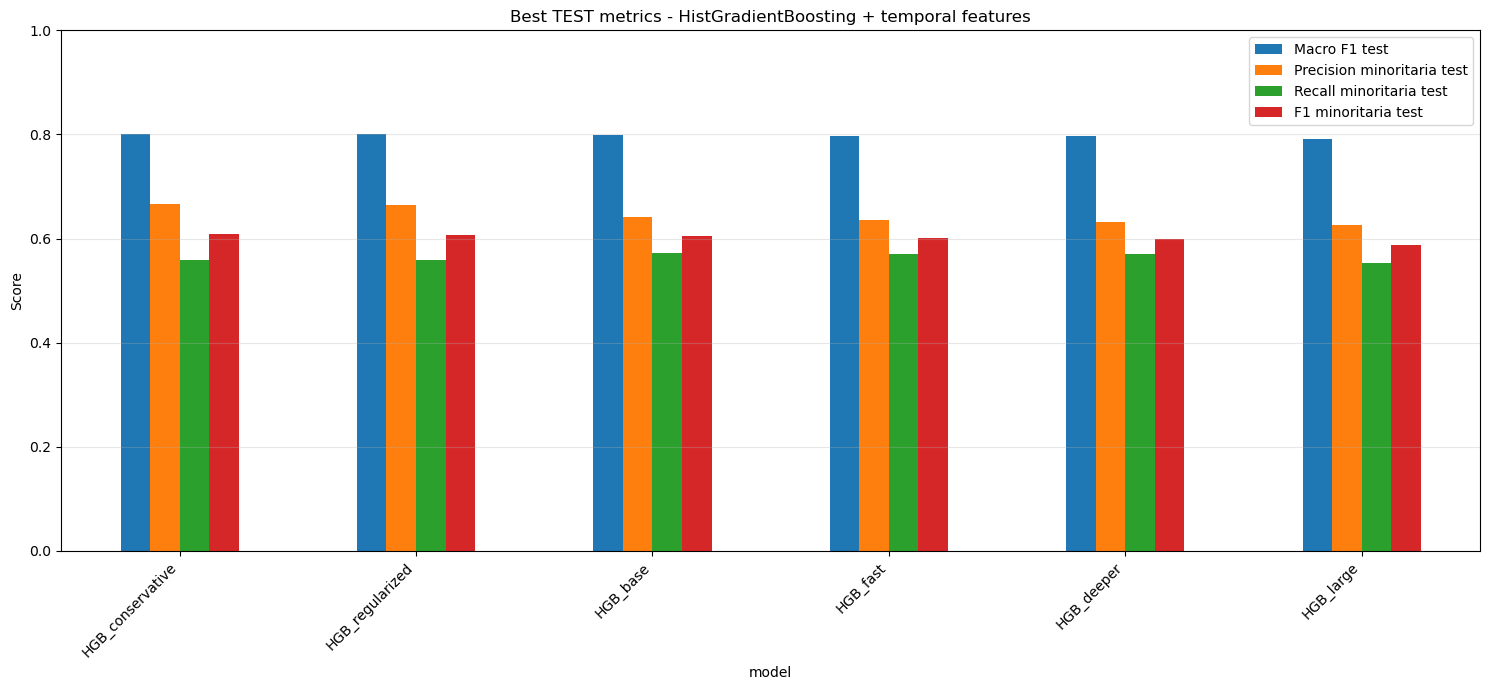

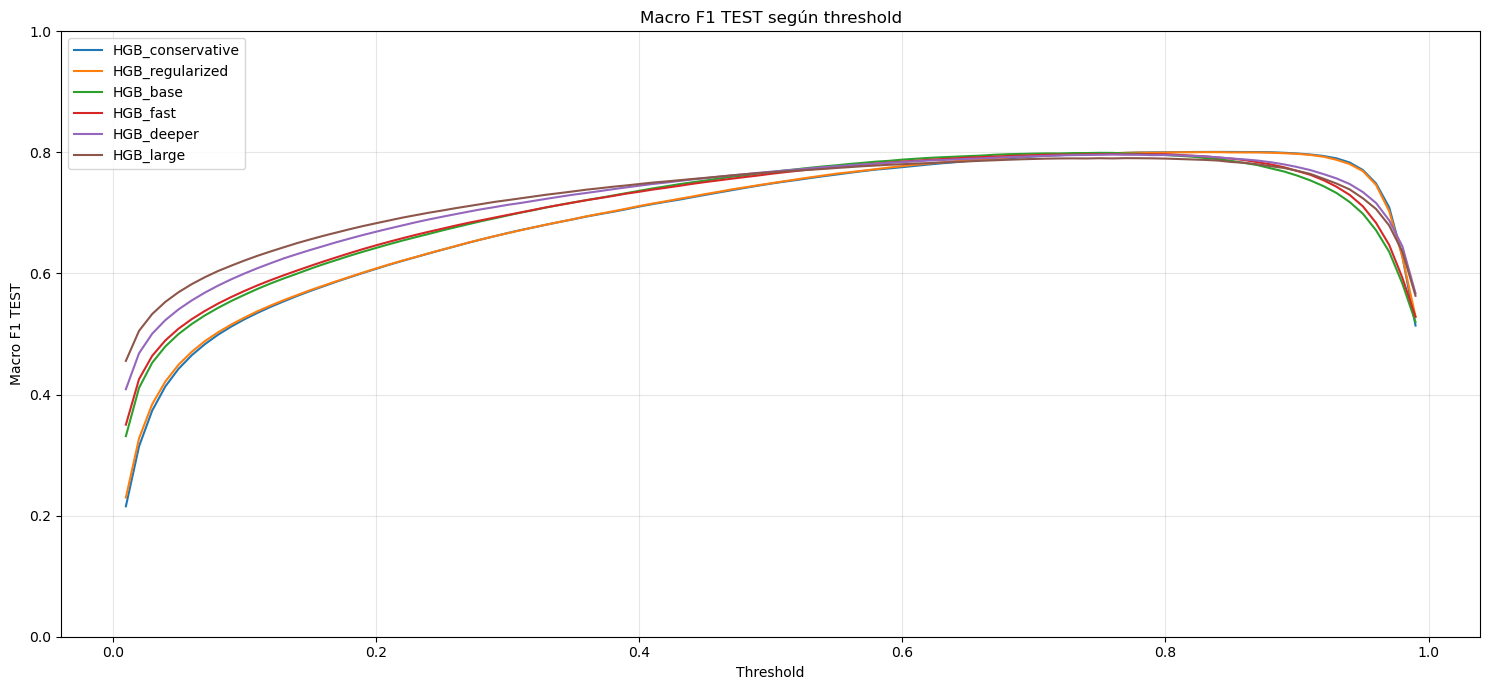

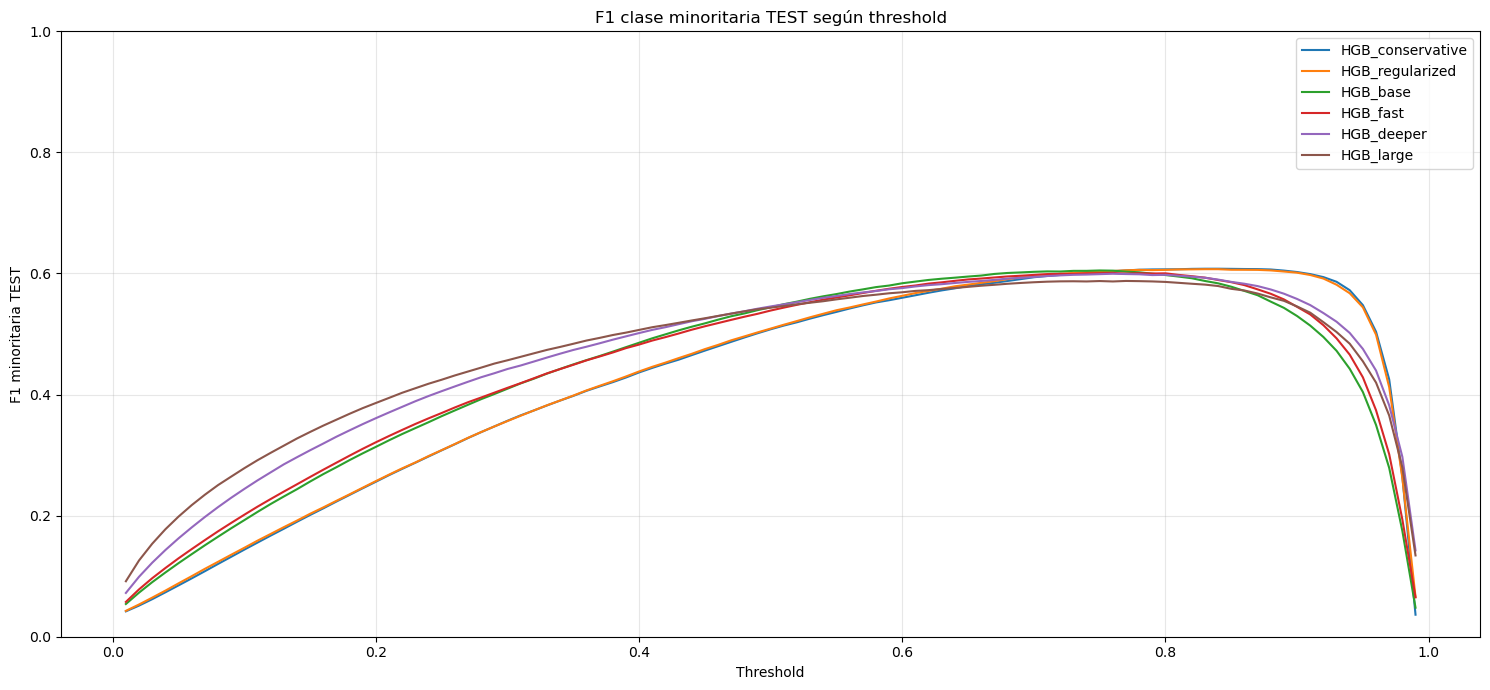

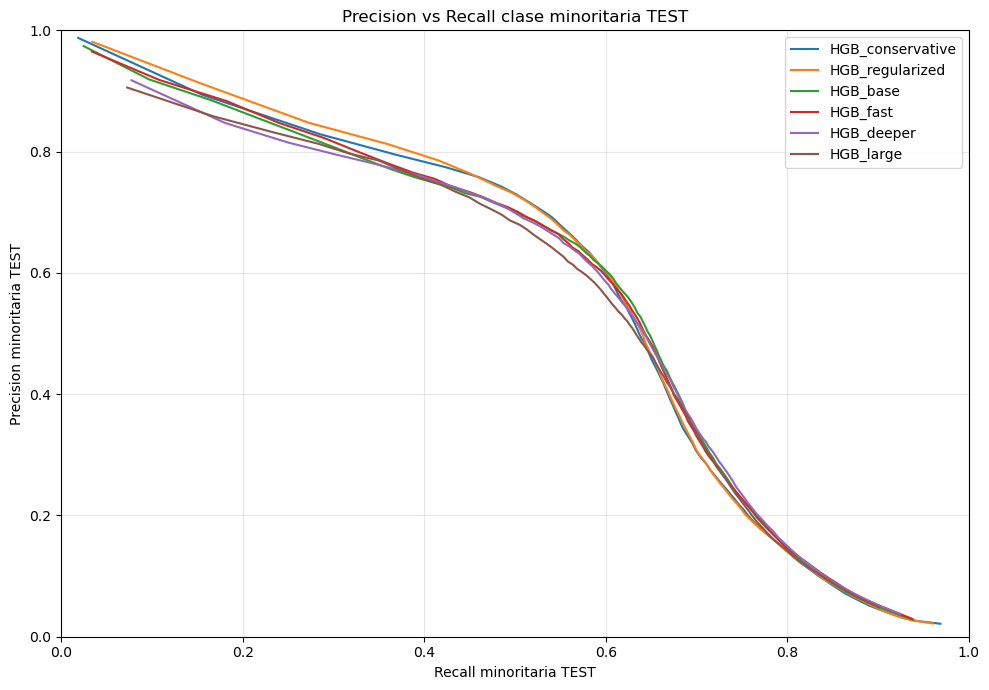


BEST TEST MODEL: HGB_conservative
model                      HGB_conservative
threshold                              0.84
macro_f1_test                      0.800859
weighted_f1_test                   0.987326
accuracy_test                      0.987846
precision_minority_test            0.665792
recall_minority_test               0.559255
f1_minority_test                   0.607891
precision_majority_test            0.992468
recall_majority_test                0.99519
f1_majority_test                   0.993827
tn                                  1238425
fp                                     5986
fn                                     9398
tp                                    11925


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURES
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURE: ONLY estado_lag_4
# ─────────────────────────────────────────────

print("Creating temporal feature: estado_lag_4...")

group_col = "Denominació / Denominación"

grouped = df.groupby(group_col)

# Only temporal feature:
# lag_4 = estado observado 4 pasos antes = 1 hora antes si tus datos son cada 15 min
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. LABEL ENCODING
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. USE ALL FEATURES
# ─────────────────────────────────────────────

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ALL features ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

continuous_cols = [
    "tmed",
    "prec",
    "tmin",
    "tmax",
    "sol",
    "minutes",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. RESAMPLING TRAIN ONLY
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. HISTGRADIENTBOOSTING MODELS
# ─────────────────────────────────────────────

models = {
    "HGB_base": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_deeper": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=127,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_regularized": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=1.0,
        random_state=42
    ),

    "HGB_conservative": HistGradientBoostingClassifier(
        max_iter=700,
        learning_rate=0.02,
        max_leaf_nodes=31,
        min_samples_leaf=150,
        l2_regularization=2.0,
        random_state=42
    ),

    "HGB_fast": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_large": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=255,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. THRESHOLDS 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. TRAIN + EVALUATE ON TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        all_results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. RESULTS
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics - HistGradientBoosting + temporal features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. BEST MODEL
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

HISTGRADIENTBOOSTING CON SOLO ESTADO_LAG_4

Creating temporal feature: estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Using ONLY estado_lag_4 as feature (1):
['estado_lag_4']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES

----------------------------------------------------------------------------------------------------
Training model: HGB_base
----------------------------------------------------------------------------------------------------

Best TEST result:
Threshold:          0.38
Macro F1 test:      0.7823
Weighted F1 test:   0.9856
Accuracy test:      0.9856
Precision minority: 0.5722
Recall minority:    0.5717
F1 minority:        0.5719

Confusion matrix:
[[1235295    9116]
 [   9132   12191]]

----------------------------------------------------------------------------------------------------
Training model: HGB_deeper
------------------------------------------

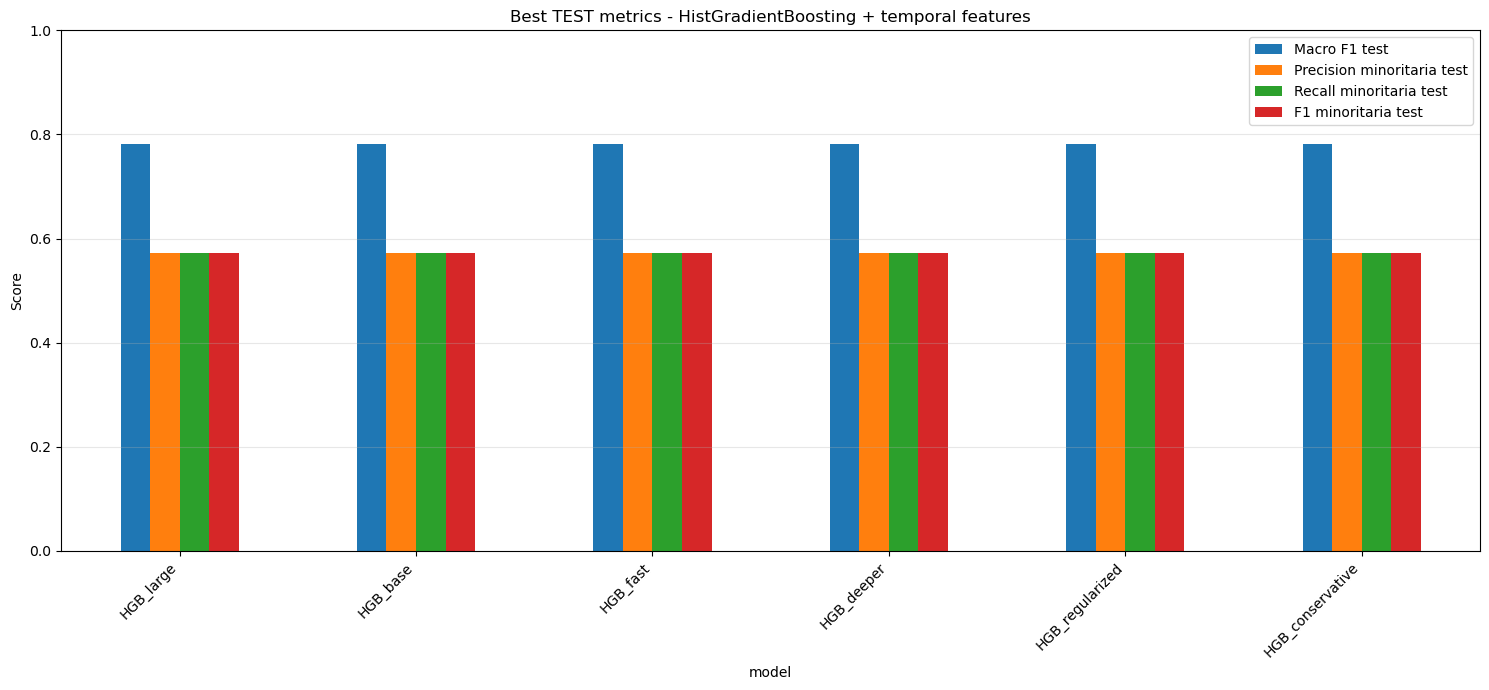

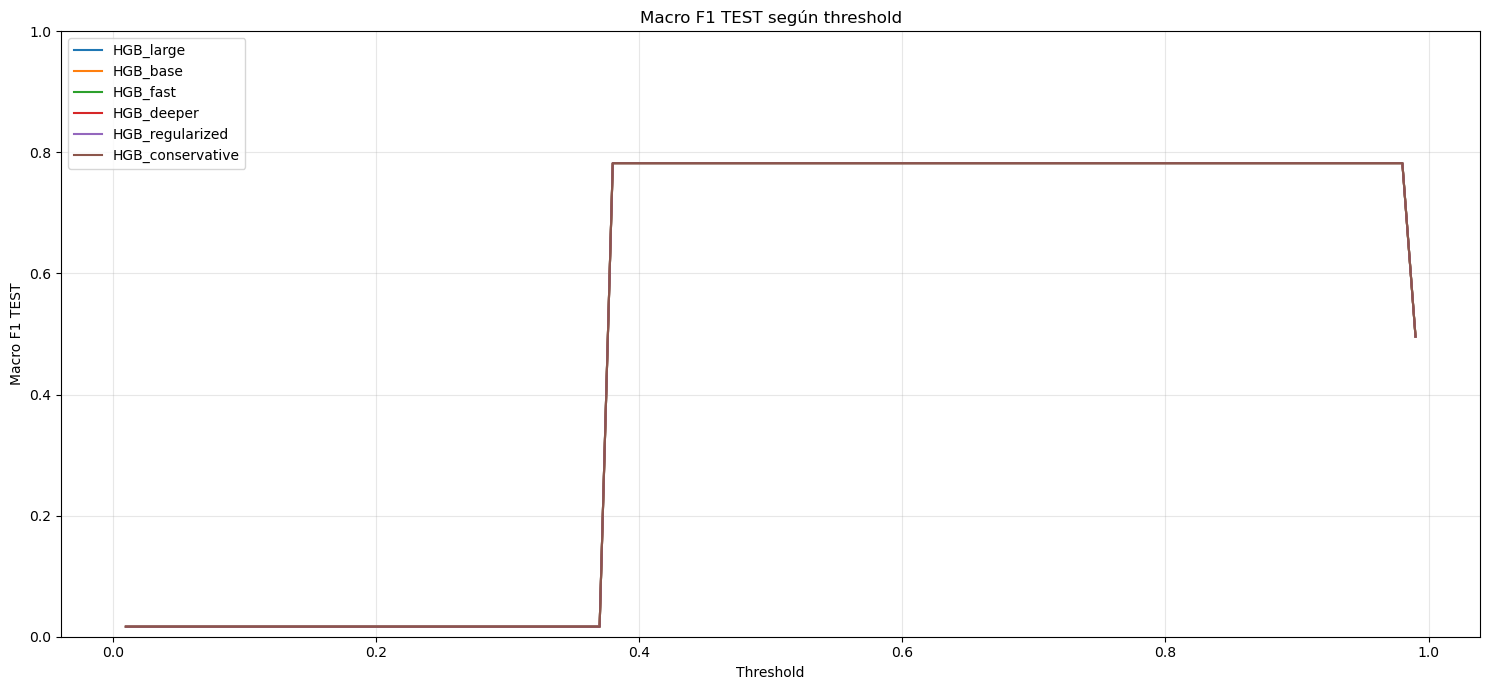

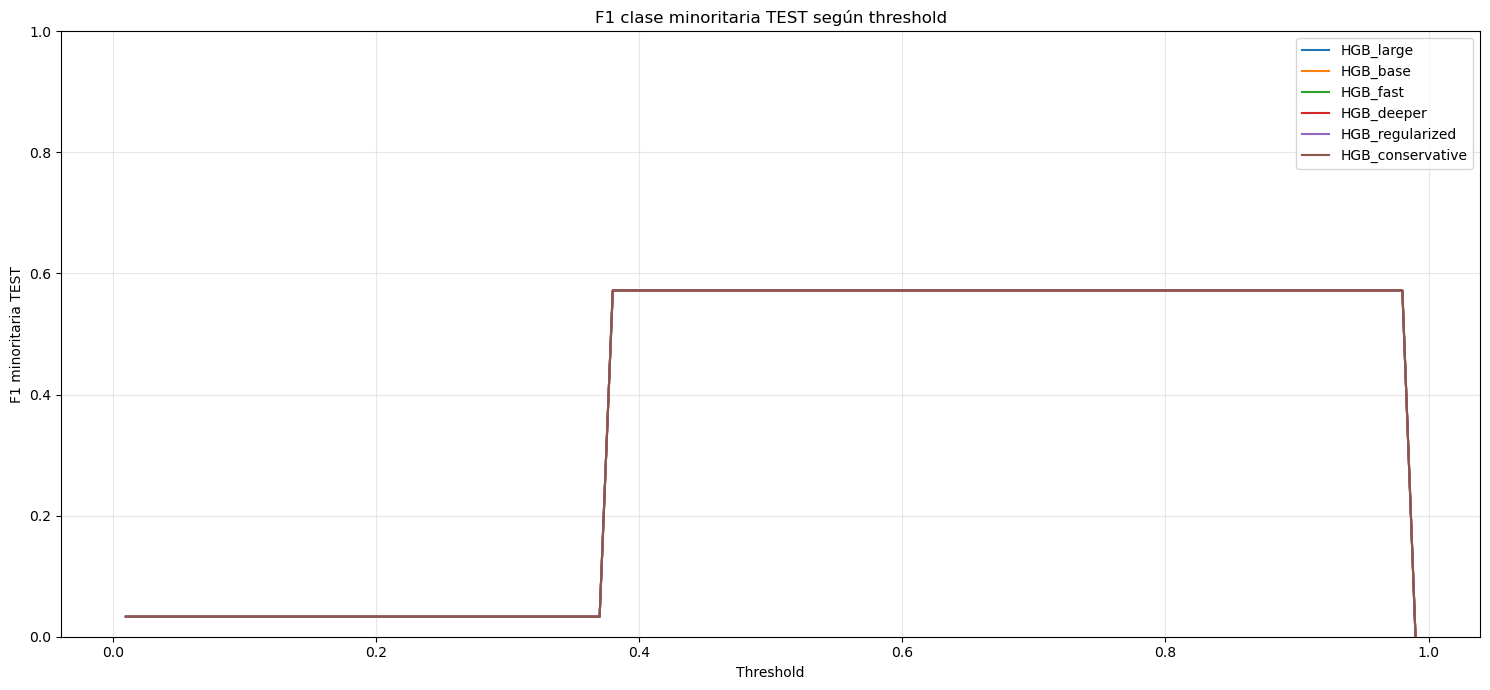

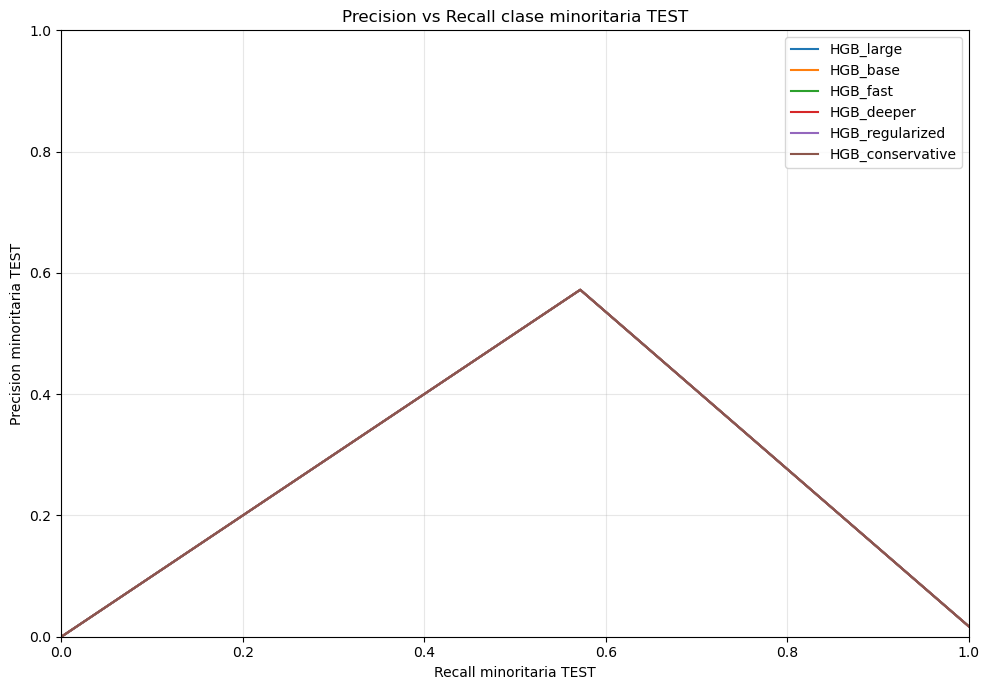


BEST TEST MODEL: HGB_large
model                      HGB_large
threshold                       0.98
macro_f1_test               0.782306
weighted_f1_test             0.98558
accuracy_test               0.985583
precision_minority_test     0.572159
recall_minority_test         0.57173
f1_minority_test            0.571945
precision_majority_test     0.992662
recall_majority_test        0.992674
f1_majority_test            0.992668
tn                           1235295
fp                              9116
fn                              9132
tp                             12191


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURES
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURE: ONLY estado_lag_4
# ─────────────────────────────────────────────

print("Creating temporal feature: estado_lag_4...")

group_col = "Denominació / Denominación"

grouped = df.groupby(group_col)

# Only temporal feature:
# lag_4 = estado observado 4 pasos antes = 1 hora antes si tus datos son cada 15 min
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. LABEL ENCODING
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. USE ALL FEATURES
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 6. USE ONLY estado_lag_4
# ─────────────────────────────────────────────

feature_cols = [
    "estado_lag_4"
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ONLY estado_lag_4 as feature ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

continuous_cols = []

scaler = StandardScaler()

# No scaling needed because estado_lag_4 is binary


# ─────────────────────────────────────────────
# 8. RESAMPLING TRAIN ONLY
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. HISTGRADIENTBOOSTING MODELS
# ─────────────────────────────────────────────

models = {
    "HGB_base": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_deeper": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=127,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_regularized": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=1.0,
        random_state=42
    ),

    "HGB_conservative": HistGradientBoostingClassifier(
        max_iter=700,
        learning_rate=0.02,
        max_leaf_nodes=31,
        min_samples_leaf=150,
        l2_regularization=2.0,
        random_state=42
    ),

    "HGB_fast": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_large": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=255,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. THRESHOLDS 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. TRAIN + EVALUATE ON TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        all_results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. RESULTS
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics - HistGradientBoosting + temporal features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. BEST MODEL
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

HISTGRADIENTBOOSTING CON TEMPORAL FEATURES

Creating temporal features...
Dropped 1152 rows
Remaining rows: 5456090

Train rows: 4190356
Test rows: 1265734

Using ALL features (44):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES

--------------------------------

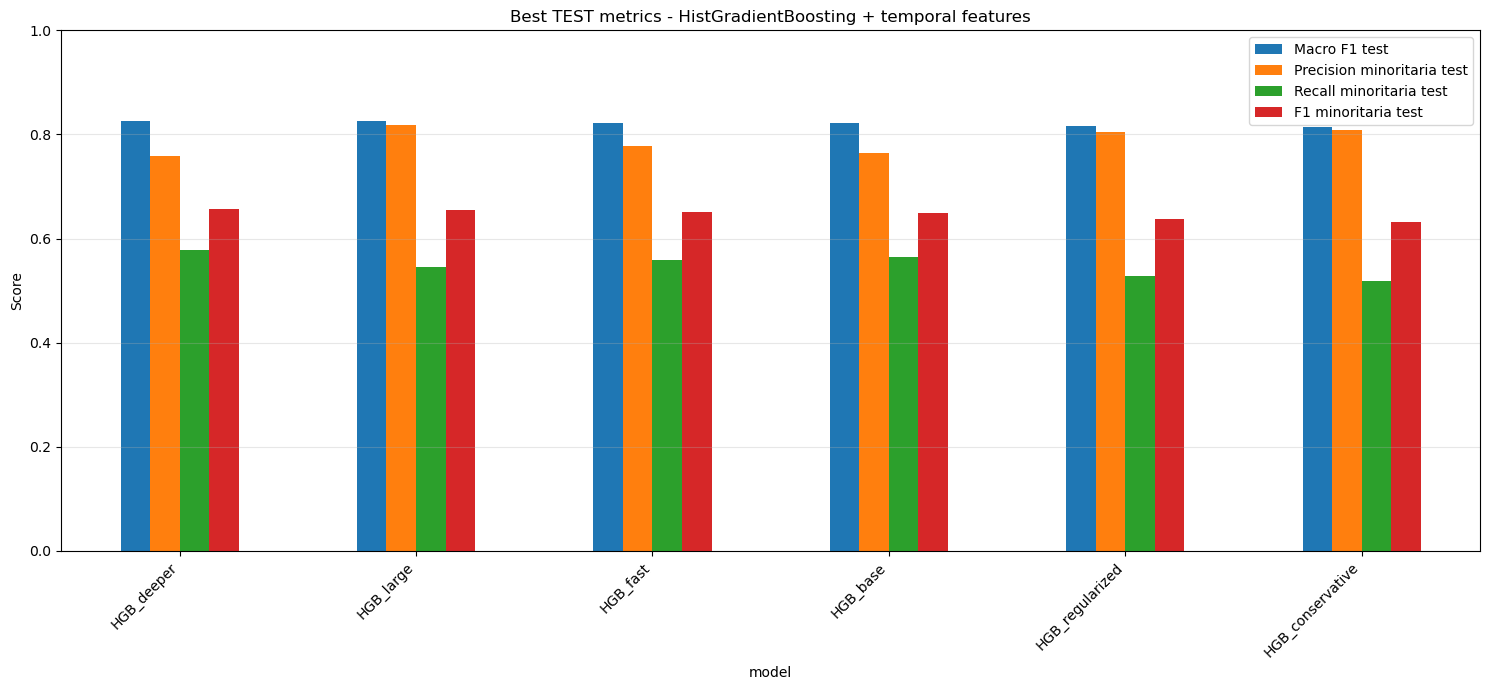

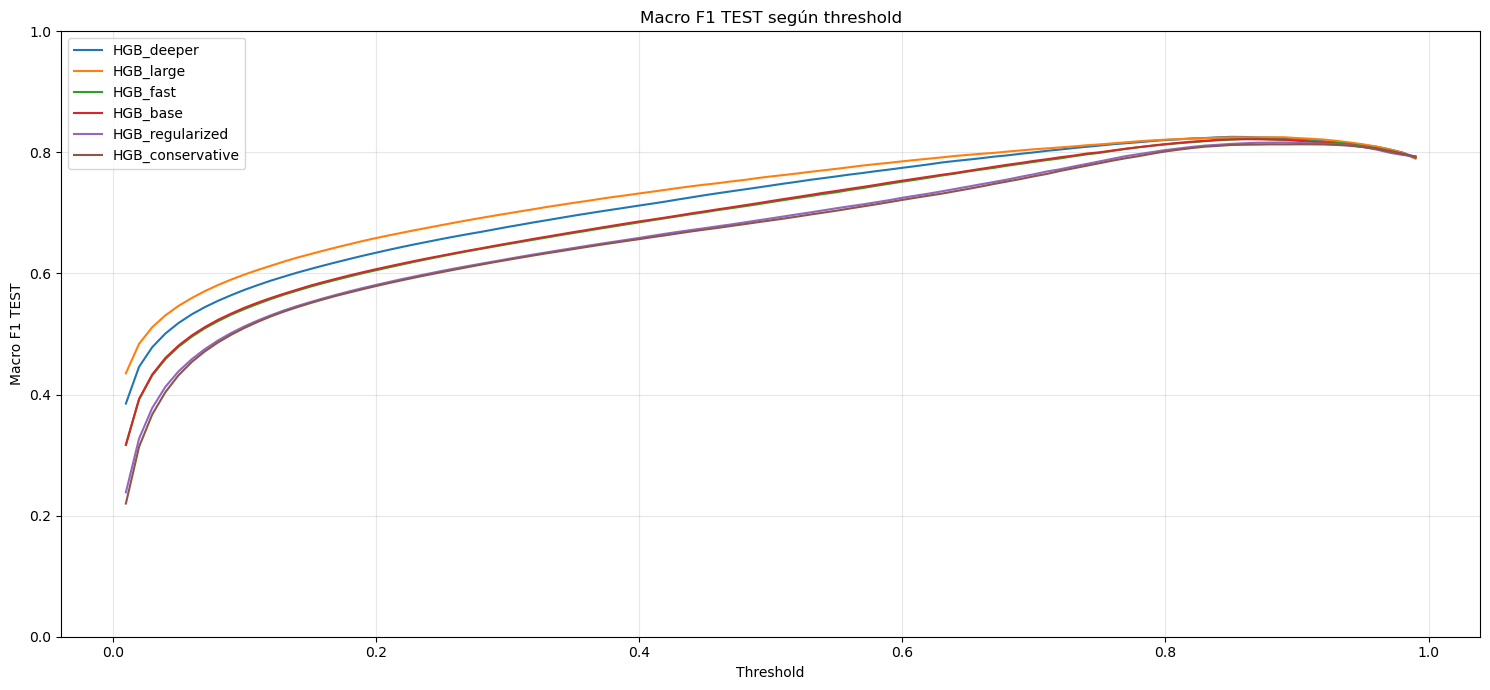

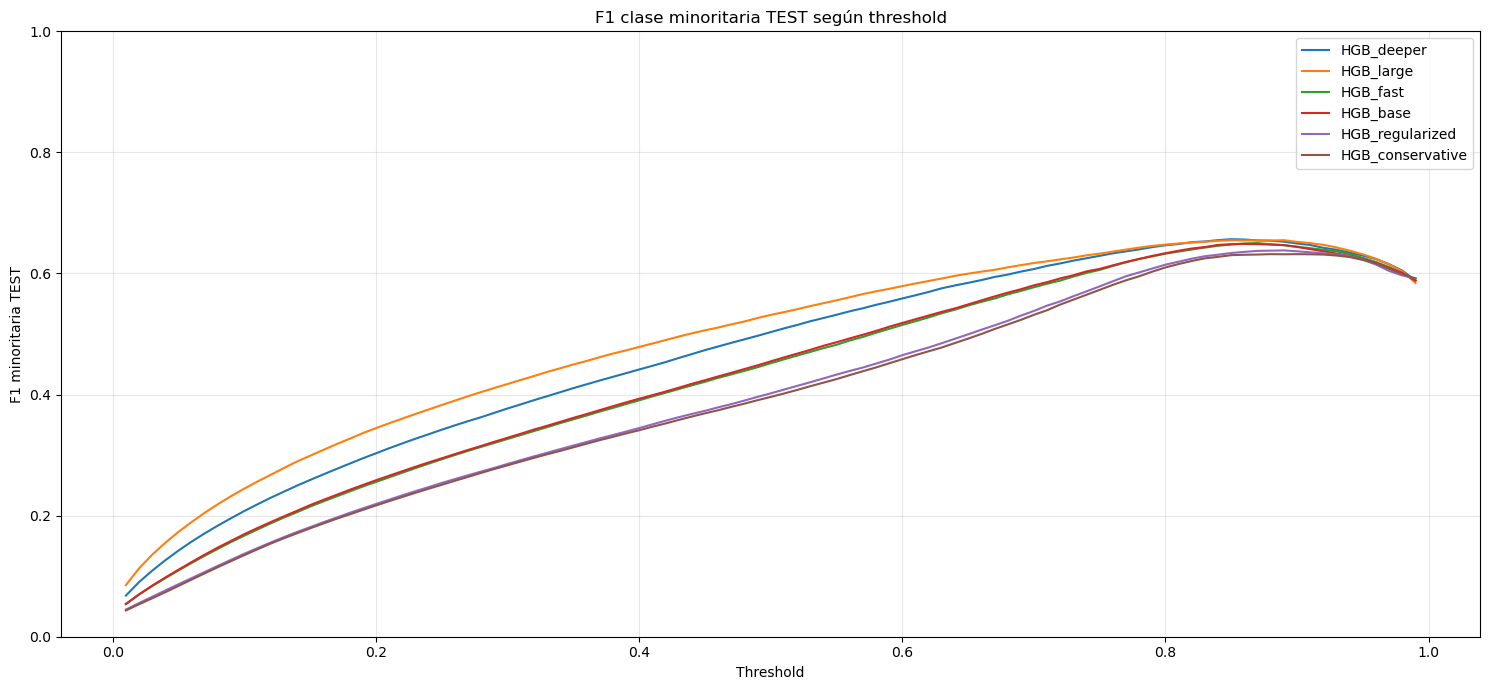

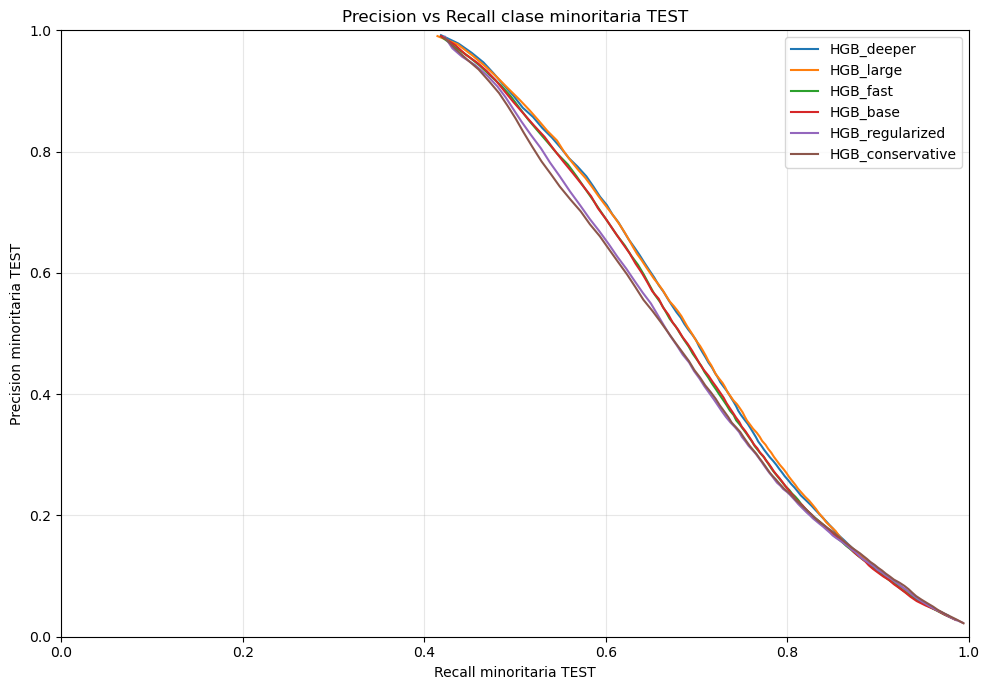


BEST TEST MODEL: HGB_deeper
model                      HGB_deeper
threshold                        0.85
macro_f1_test                0.825716
weighted_f1_test             0.989129
accuracy_test                0.989807
precision_minority_test      0.759202
recall_minority_test         0.578436
f1_minority_test             0.656605
precision_majority_test      0.992806
recall_majority_test         0.996856
f1_majority_test             0.994827
tn                            1240499
fp                               3912
fn                               8989
tp                              12334

FEATURE IMPORTANCE - BEST MODEL: HGB_deeper
                    feature  importance  importance_std  importance_pct
                   hour_sin    0.256006        0.000375        0.229263
                   hour_cos    0.238761        0.000401        0.213819
                    minutes    0.229583        0.000723        0.205600
               is_rush_hour    0.094032        0.000508        0.084

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURES
# ─────────────────────────────────────────────

print("Creating temporal features...")

group_col = "Denominació / Denominación"

grouped = df.groupby(group_col)

# Main lag
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# Rolling windows before lag_4
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=4, min_periods=1).mean()
)

df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(window=4, min_periods=1).mean()
)

# Trend: positive = worsening, negative = clearing
df["estado_trend"] = (
    df["estado_rolling_4_to_8"] -
    df["estado_rolling_8_to_12"]
)


# Consecutive congested steps ending at lag_4

def consecutive_congestion_lag4(x):
    values = x.shift(4).fillna(0).astype(int).values
    result = np.zeros(len(values), dtype=np.float32)
    count = 0

    for i, v in enumerate(values):
        if v == 1:
            count += 1
        else:
            count = 0
        result[i] = count

    return pd.Series(result, index=x.index)


df["consecutive_congested_steps"] = grouped["Estado_binary"].transform(
    consecutive_congestion_lag4
)


# Time since last congestion, measured in 15-min steps, using info available before lag_4

def time_since_last_congestion_lag4(x):
    values = x.shift(4).fillna(0).astype(int).values
    result = np.zeros(len(values), dtype=np.float32)

    last_seen = None

    for i, v in enumerate(values):
        if v == 1:
            last_seen = i
            result[i] = 0
        else:
            if last_seen is None:
                result[i] = 999
            else:
                result[i] = i - last_seen

    return pd.Series(result, index=x.index)


df["time_since_last_congestion"] = grouped["Estado_binary"].transform(
    time_since_last_congestion_lag4
)


before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
        "consecutive_congested_steps",
        "time_since_last_congestion",
    ]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. LABEL ENCODING
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. USE ALL FEATURES
# ─────────────────────────────────────────────

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ALL features ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

continuous_cols = [
    "tmed",
    "prec",
    "tmin",
    "tmax",
    "sol",
    "minutes",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
]


continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. RESAMPLING TRAIN ONLY
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. HISTGRADIENTBOOSTING MODELS
# ─────────────────────────────────────────────

models = {
    "HGB_base": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_deeper": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=127,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_regularized": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=1.0,
        random_state=42
    ),

    "HGB_conservative": HistGradientBoostingClassifier(
        max_iter=700,
        learning_rate=0.02,
        max_leaf_nodes=31,
        min_samples_leaf=150,
        l2_regularization=2.0,
        random_state=42
    ),

    "HGB_fast": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_large": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=255,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. THRESHOLDS 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. TRAIN + EVALUATE ON TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        all_results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. RESULTS
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics - HistGradientBoosting + temporal features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. BEST MODEL
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

# ─────────────────────────────────────────────
# 15. PERMUTATION IMPORTANCE - BEST HGB MODEL
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 15. FEATURE IMPORTANCE - BEST HGB MODEL
# ─────────────────────────────────────────────

from sklearn.inspection import permutation_importance

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

# Para que no tarde demasiado
X_importance = X_test.sample(
    n=min(50000, len(X_test)),
    random_state=42
)

y_importance = y_test.loc[X_importance.index]

perm_importance = permutation_importance(
    best_model,
    X_importance,
    y_importance,
    scoring="f1_macro",
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std,
}).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum()
)

print("\n" + "=" * 100)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 100)

print(importance_df.to_string(index=False))